<center>
<a href="http://www.insa-toulouse.fr/" ><img src="http://www.math.univ-toulouse.fr/~besse/Wikistat/Images/logo-insa.jpg" style="float:left; max-width: 120px; display: inline" alt="INSA"/></a> 

</center>

# Projet Machine Learning — 4MA 2025-2026
## Prédiction du Risque de Maladie Cardiovasculaire
### INSA Toulouse
---

**Jeu de données** : *Cardiovascular Disease Risk Prediction Dataset* : 15 000 patients   
**Langage** : Python   
**Objectifs** :
- Partie 1 : Prédiction de `Heart_Disease_Risk` 
- Partie 2 : Prédiction de `Cholesterol_LDL` 

> Ce notebook vient compléter l'étude réalisée en R. Les conclusions sont comparables, > mais Python offre une exécution plus rapide, notamment pour la validation croisée.

### 0. Importation des bibliothèques et chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import time 

import warnings
warnings.filterwarnings('ignore')
randomseed = 111 

In [2]:
#Récupération des données
df = pd.read_csv("healthcare_synthetic_data.csv")
print(df.shape)
df.head()


(15000, 19)


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


In [3]:
# Vérification des types de données et des valeurs manquantes
print("Types des variables :")
print(df.dtypes)
print("\nValeurs manquantes :")
print(df.isnull().sum())

# Prétraitement des données
df = df.drop(columns=["Patient_ID"])
for col in ["Gender", "Smoking_Status", "Family_History", "Heart_Disease_Risk"]:
    df[col] = pd.Categorical(df[col], ordered=False)
df["Alcohol_Consumption"] = pd.Categorical(
    df["Alcohol_Consumption"], categories=[0, 1, 2], ordered=True)
df["Physical_Activity_Level"] = pd.Categorical(
    df["Physical_Activity_Level"], categories=[0, 1, 2, 3], ordered=True)
print(df.dtypes)
df.describe()


Types des variables :
Patient_ID                  object
Age                          int64
Gender                       int64
Height_cm                  float64
Weight_kg                  float64
BMI                        float64
Systolic_BP                  int64
Diastolic_BP                 int64
Cholesterol_Total            int64
Cholesterol_LDL              int64
Cholesterol_HDL              int64
Fasting_Blood_Sugar          int64
Smoking_Status               int64
Alcohol_Consumption          int64
Physical_Activity_Level      int64
Family_History               int64
Stress_Level                 int64
Sleep_Hours                  int64
Heart_Disease_Risk           int64
dtype: object

Valeurs manquantes :
Patient_ID                 0
Age                        0
Gender                     0
Height_cm                  0
Weight_kg                  0
BMI                        0
Systolic_BP                0
Diastolic_BP               0
Cholesterol_Total          0
Cholesterol_LDL 

,Age,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Stress_Level,Sleep_Hours
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,54.538133,165.336767,75.252573,27.446080,135.117667,90.541267,216.248000,140.355267,43.307867,99.670200,5.503667,6.506067
std,11.875294,9.186313,14.110559,4.134953,11.260634,8.443095,22.692222,17.914089,5.963153,15.261355,2.874277,1.212626
min,25.000000,138.500000,33.700000,14.500000,90.000000,60.000000,127.000000,70.000000,20.000000,60.000000,1.000000,4.000000
25%,46.000000,158.500000,65.200000,24.500000,127.000000,85.000000,201.000000,128.000000,39.000000,89.000000,3.000000,6.000000
50%,55.000000,164.700000,73.900000,27.200000,135.000000,91.000000,216.000000,140.000000,43.000000,99.000000,5.500000,7.000000
75%,63.000000,172.000000,83.900000,30.000000,143.000000,96.000000,231.000000,152.000000,47.000000,110.000000,8.000000,7.000000
max,85.000000,198.100000,150.100000,46.100000,182.000000,120.000000,303.000000,210.000000,68.000000,167.000000,10.000000,10.000000


### 1. Prédiction du risque d’accident cardiaque

In [4]:
X = df.drop(columns=["Heart_Disease_Risk"])
y = df["Heart_Disease_Risk"]

Les données sont séparées en deux ensembles : 80 % pour l’apprentissage du modèle et 20 % pour l’évaluation sur des données de test jamais vues auparavant.

In [5]:

# Division en ensembles d'apprentissage et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=randomseed)

# Vérification des tailles des ensembles
print("Taille apprentissage :", X_train.shape[0])
print("Taille test :", X_test.shape[0])

# Normalisation
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)



Taille apprentissage : 12000
Taille test : 3000


Cette étape est essentielle car elle permet d'estimer les performances réelles du modèle sur des données qu'il n'a jamais vues durant l'apprentissage. Sans cette séparation, le modèle pourrait simplement mémoriser les données d'entraînement et afficher de bonnes performances sans pour autant être capable de généraliser à de nouveaux patients.On retient 20% des données pour le test, soit 3 000 patients.

#### 1.1 Modèle Linéaire Généralisé

Le modèle linéaire généralisé (régression logistique) constitue une première approche de référence pour prédire le risque d’accident cardiaque à partir de l’ensemble des variables explicatives.

##### 1.1.1 Sans pénalisation et sans séléction des variables 

Dans cette première version, aucune sélection de variables ni pénalisation n’est appliquée afin d’évaluer les performances du modèle sur l’ensemble complet des variables disponibles.

In [6]:
Xr_train = X_train_scaled
Xr_test = X_test_scaled
ModelLin = LogisticRegression(random_state=randomseed, max_iter=1000)
ModelLin.fit(Xr_train, y_train)
score = ModelLin.score(Xr_test, y_test)
print("Score du modèle de régression logistique :", score)
y_pred = ModelLin.predict(Xr_test)
print("Matrice de confusion :\n", confusion_matrix(y_test, y_pred))

Score du modèle de régression logistique : 0.753
Matrice de confusion :
 [[1426  335]
 [ 406  833]]


In [7]:
ModelLin = LogisticRegression(random_state=randomseed, max_iter=1000)
ModelLin.fit(Xr_train, y_train)
score = ModelLin.score(Xr_test, y_test)
print("Score du modèle de régression logistique :", score)
y_pred = ModelLin.predict(Xr_test)
print("Matrice de confusion :\n", confusion_matrix(y_test, y_pred))

Score du modèle de régression logistique : 0.753
Matrice de confusion :
 [[1426  335]
 [ 406  833]]


Variables éliminées : 0


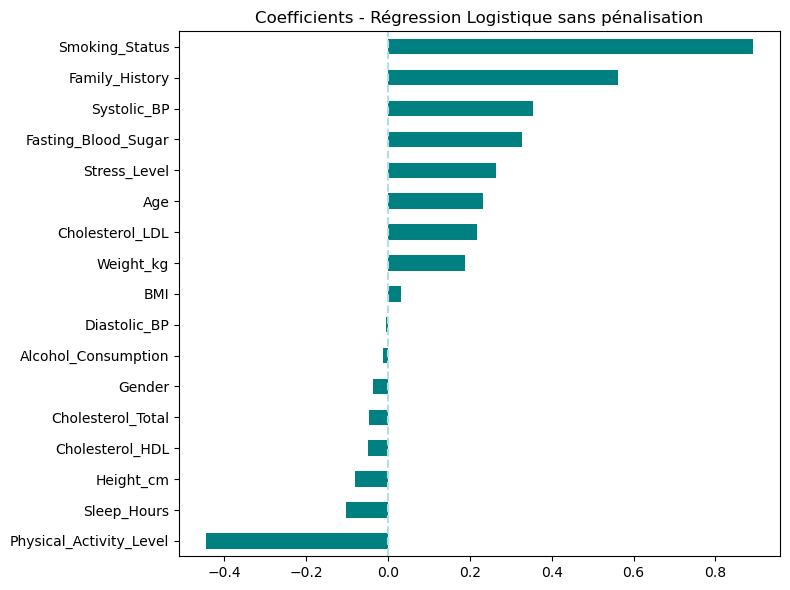

In [8]:
# Visualisation des oefficients
coef = pd.Series(ModelLin.coef_[0], index=X.columns)
print(f"Variables éliminées : {sum(coef == 0)}")
coef.sort_values().plot(kind='barh', figsize=(8,6), color='teal')
plt.title("Coefficients - Régression Logistique sans pénalisation")
plt.axvline(0, color='powderblue', linestyle='--')
plt.tight_layout()
plt.show()

##### 1.1.2 Pénalisation LASSO L1 

La pénalisation LASSO (L1) est maintenant introduite afin de réduire la complexité du modèle et d’identifier automatiquement les variables les plus importantes.


In [ ]:
param = [{"C": [0.001,0.01, 0.1, 1, 10, 100]}]
logit = GridSearchCV(LogisticRegression(penalty="l1",solver="liblinear"), param_grid=param, cv=10,n_jobs=-1)
logit0pt=logit.fit(Xr_train, y_train)
logit0pt.best_params_["C"]
print("Meilleur score :",logit0pt.best_score_)
print("Meilleur paramètre C :", logit0pt.best_params_)

yChap = logit0pt.predict(Xr_test)
print("Score du modèle de régression logistique optimisé :", accuracy_score(y_test, yChap))

Meilleur score : 0.7355833333333333
Meilleur paramètre C : {'C': 10}
Score du modèle de régression logistique optimisé : 0.753


Variables éliminées : 0


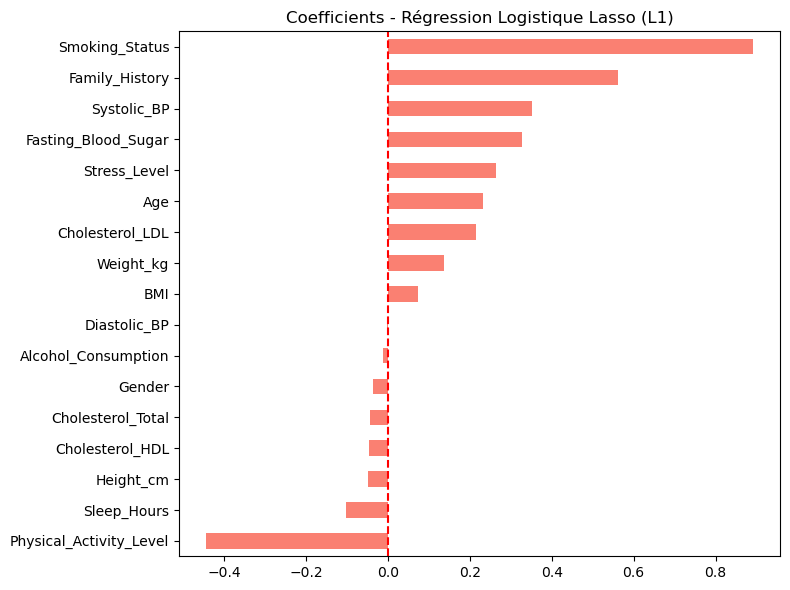

In [10]:
# Visualisation des coefficients
coef_lasso = pd.Series(logit0pt.best_estimator_.coef_[0], index=X.columns)
print(f"Variables éliminées : {sum(coef_lasso == 0)}")
coef_lasso.sort_values().plot(kind='barh', figsize=(8,6), color='salmon')
plt.title("Coefficients - Régression Logistique Lasso (L1)")
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

Avec le C optimal trouvé par validation croisée, le Lasso ne met aucun coefficient à zéro. Les résultats avec pénalisation Lasso (C optimal) sont proches de celles sans pénalisation. Pour un peu pousser l'effet de Lasso sur notre modèle on teste différente valeur de C et voir les variables qui on étés supprimées.

In [11]:
# Effet de C sur la sélection de variables 
for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    logit_test = LogisticRegression(penalty="l1", solver="liblinear",
                                     C=C, max_iter=1000)
    logit_test.fit(Xr_train, y_train)
    n_zero = sum(logit_test.coef_[0] == 0)
    acc = accuracy_score(y_test, logit_test.predict(Xr_test))
    print(f"C={C:6} | Variables éliminées : {n_zero:2} | Accuracy : {acc:.4f}")

C= 0.001 | Variables éliminées : 14 | Accuracy : 0.7173
C=  0.01 | Variables éliminées :  5 | Accuracy : 0.7510
C=   0.1 | Variables éliminées :  2 | Accuracy : 0.7513
C=     1 | Variables éliminées :  0 | Accuracy : 0.7527
C=    10 | Variables éliminées :  0 | Accuracy : 0.7530
C=   100 | Variables éliminées :  0 | Accuracy : 0.7530


La pénalisation LASSO montre ici que plusieurs variables peuvent être supprimées lorsque la pénalisation devient plus forte (petites valeurs de C), mais cela entraîne également une baisse des performances.  

Le meilleur compromis est obtenu pour \( C = 1 \), avec une accuracy proche du modèle sans pénalisation et sans suppression de variables. Les performances du modèle semblent donc relativement stables et peu sensibles à la sélection automatique des variables.

### 1.2 Support Vector Machine (SVM)

Dans cette partie, nous appliquons la méthode des Support Vector Machines pour la classification de la variable *Heart_Disease_Risk*. 

Nous commençons par un modèle SVM avec noyau linéaire, puis un noyau gaussien (RBF). 
Enfin, nous optimisons les hyperparamètres du modèle par validation croisée afin d’améliorer ses performances.

##### 1.2.1 SVM linéaire

In [12]:
from sklearn.svm import SVC

ts = time.time()

svm_linear = SVC(kernel='linear', random_state=randomseed)
svm_linear.fit(X_train_scaled, y_train)

score_linear = svm_linear.score(X_test_scaled, y_test)
y_pred_linear = svm_linear.predict(X_test_scaled)

te = time.time()

In [13]:
print("Score SVM linéaire : %f, Temps : %f secondes" % (score_linear, te - ts))

pd.DataFrame(confusion_matrix(y_test, y_pred_linear),
             index=["0 réel","1 réel"],
             columns=["0 prédit","1 prédit"])

Score SVM linéaire : 0.744667, Temps : 74.353904 secondes


,0 prédit,1 prédit
0 réel,1428,333
1 réel,433,806


Le modèle SVM linéaire obtient une accuracy d’environ **0.745**, ce qui constitue une performance correcte.

La matrice de confusion montre que :
- Le modèle prédit relativement bien les individus à faible risque (classe 0)
- Cependant, il commet encore un nombre non négligeable d’erreurs sur la classe 1 (risque élevé)

Cela suggère que la relation entre les variables explicatives et la variable cible n’est pas strictement linéaire.

##### 1.2.2 SVM avec noyau gaussien (RBF)

Le noyau gaussien (RBF) est maintenant utilisé afin de prendre en compte d’éventuelles relations non linéaires entre les variables explicatives et le risque cardiovasculaire.
Il a été retenu parmi les différents noyaux possibles car il offre une plus grande flexibilité et permet de projeter les données dans un espace de dimension élevée afin de mieux capturer des relations complexes entre les variables.

In [15]:
ts = time.time()

svm_rbf = SVC(kernel='rbf', gamma='auto', random_state=randomseed)
svm_rbf.fit(X_train_scaled, y_train)

score_rbf = svm_rbf.score(X_test_scaled, y_test)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

te = time.time()

In [16]:
print("Score SVM RBF : %f, Temps : %f secondes" % (score_rbf, te - ts))

pd.DataFrame(confusion_matrix(y_test, y_pred_rbf),
             index=["0 réel","1 réel"],
             columns=["0 prédit","1 prédit"])

Score SVM RBF : 0.743333, Temps : 39.850900 secondes


,0 prédit,1 prédit
0 réel,1433,328
1 réel,442,797


Le modèle SVM avec noyau gaussien (RBF) obtient une accuracy d’environ **0.743**, très proche de celle du modèle linéaire.

La matrice de confusion montre une répartition des erreurs similaire au modèle linéaire, avec :
- Une bonne détection de la classe 0
- Des difficultés persistantes sur la classe 1

Le noyau RBF, plus flexible, n’apporte pas ici d’amélioration significative, ce qui peut indiquer que les relations dans les données ne sont pas fortement non linéaires ou que les paramètres ne sont pas encore optimisés.

##### 1.2.3 Optimisation des hyperparamètres 

In [17]:
from sklearn.model_selection import RandomizedSearchCV

ts = time.time()

param_dist = {
    "C": np.logspace(-2, 2, 10),      # valeurs entre 0.01 et 100
    "gamma": np.logspace(-3, 1, 10)   # valeurs entre 0.001 et 10
}

svm_random = RandomizedSearchCV(
    SVC(kernel='rbf'),
    param_distributions=param_dist,
    n_iter=10,        # nombre de tests
    cv=3,             # validation croisée
    n_jobs=-1,
    random_state=randomseed
)

svmOpt = svm_random.fit(X_train_scaled, y_train)

te = time.time()

In [18]:
print("Meilleur score : %f" % svmOpt.best_score_)
print("Meilleurs paramètres :", svmOpt.best_params_)
print("Temps optimisation :", te - ts)

Meilleur score : 0.726083
Meilleurs paramètres : {'gamma': np.float64(0.05994842503189409), 'C': np.float64(0.5994842503189409)}
Temps optimisation : 433.17350697517395


In [20]:
best_svm = svmOpt.best_estimator_

score_opt = best_svm.score(X_test_scaled, y_test)
y_pred_opt = best_svm.predict(X_test_scaled)

print("Score SVM optimisé :", score_opt)

pd.DataFrame(confusion_matrix(y_test, y_pred_opt),
             index=["0 réel","1 réel"],
             columns=["0 prédit","1 prédit"])

Score SVM optimisé : 0.7433333333333333


,0 prédit,1 prédit
0 réel,1427,334
1 réel,436,803


Après optimisation des hyperparamètres avec RandomizedSearchCV, le modèle obtient une accuracy d’environ **0.743**, proche des modèles précédents.

Les paramètres optimaux trouvés (C ≈ 0.6, gamma ≈ 0.06) indiquent un compromis entre complexité du modèle et régularisation.

La matrice de confusion montre que :
- Le modèle reste performant pour prédire la classe 0 (faible risque)
- Les erreurs sur la classe 1 (risque élevé) persistent, ce qui indique une difficulté à détecter correctement les cas à risque

L’optimisation n’apporte pas d’amélioration significative, ce qui suggère que les performances du SVM sont limitées sur ce jeu de données.

### 1.3 Arbre de Décision Optimal (CART)

Nous appliquons maintenant un arbre de décision optimal de type CART afin de modéliser automatiquement des relations non linéaires et des interactions entre les variables explicatives.

Meilleur score (Accuracy) = 0.706750, Meilleur paramètre = {'max_depth': 5}
Erreur de prévision sur le test : 0.269000

Matrice de confusion CART :
 Observé     0    1
Prédit            
0        1452  498
1         309  741


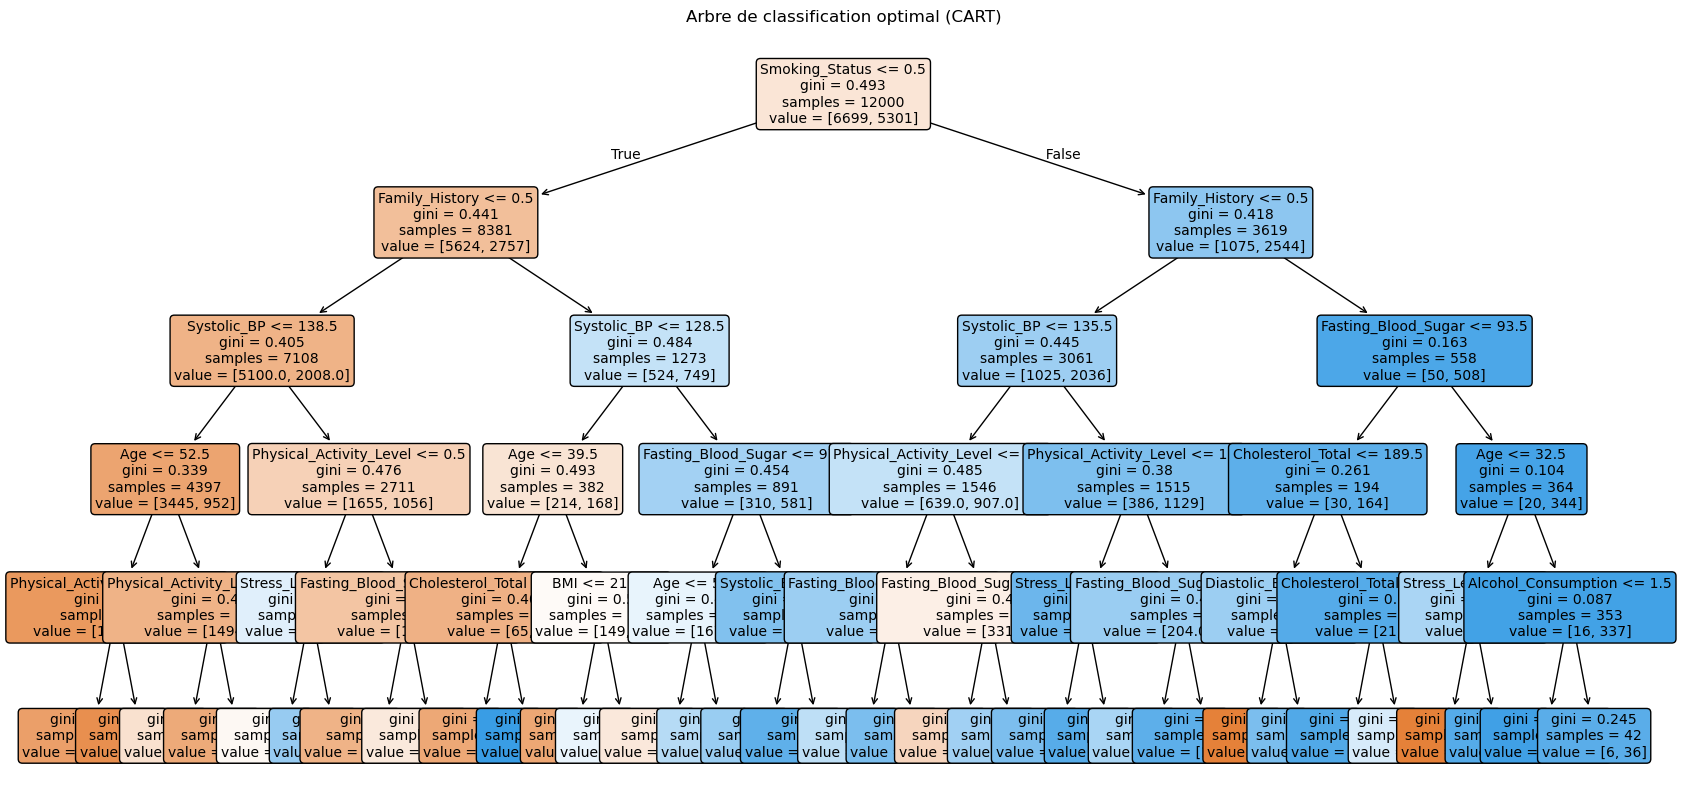

In [21]:
# Optimisation de la profondeur de l'arbre 
param = [{"max_depth": list(range(2, 10))}]
tree = GridSearchCV(DecisionTreeClassifier(random_state=randomseed), param, cv=5, n_jobs=-1)
treeOpt = tree.fit(X_train, y_train)

# Paramètre optimal
print("Meilleur score (Accuracy) = %f, Meilleur paramètre = %s" % (treeOpt.best_score_, treeOpt.best_params_))

# Estimation de l'erreur de prévision sur le test 
print("Erreur de prévision sur le test : %f" % (1 - treeOpt.score(X_test, y_test)))

# Prévision de l'échantillon test
y_chap_tree = treeOpt.predict(X_test)

# Matrice de confusion avec crosstab 
table_tree = pd.crosstab(y_chap_tree, y_test, rownames=['Prédit'], colnames=['Observé'])
print("\nMatrice de confusion CART :\n", table_tree)

# Affichage de l'arbre optimal
plt.figure(figsize=(20, 10))
# On utilise best_estimator_ pour tracer l'arbre qui a gagné le GridSearch
plot_tree(treeOpt.best_estimator_, feature_names=X_train.columns.tolist(), filled=True, rounded=True, fontsize=10)
plt.title("Arbre de classification optimal (CART)")
plt.show()

Le modèle, optimisé par validation croisée avec une profondeur maximale (max_depth) de 5, atteint une accuracy moyenne de 70,68 % lors de la validation croisée et de 73,10 % sur le jeu de test. Cette performance est inférieure à celle du modèle de régression logistique, ce qui est cohérent avec la théorie des modèles à forte variance.


L'analyse de la matrice de confusion sur le jeu de test révèle un déséquilibre dans les erreurs du modèle, avec 498 faux négatifs contre 309 faux positifs. Ce volume élevé de faux négatifs démontre que l'algorithme peine à isoler une proportion importante de la classe positive, suggérant que ces instances se situent dans des zones de l'espace des variables où la séparation des classes est incertaine. Cette difficulté est confirmée par les indices de Gini élevés (proches de 0,5) observés dans les feuilles terminales de l'arbre, indiquant que les sous-groupes finaux restent statistiquement hétérogènes malgré les divisions successives.



### 1.4 Forêt Aléatoire (Random Forest)

Afin d’améliorer les performances du modèle CART et de réduire sa variance, nous allons maintenant construire une forêt aléatoire combinant plusieurs arbres de décision.

Meilleur score (Accuracy) = 0.726583, Meilleur paramètre = {'max_features': 3}
Erreur Out-Of-Bag (OOB) : 0.283667
Erreur de prévision sur le test : 0.260667

Matrice de confusion Random Forest :
 Observé     0    1
Prédit            
0        1423  444
1         338  795

Importance des variables :
Smoking_Status 0.11052852374736231
Fasting_Blood_Sugar 0.08032603805886362
Systolic_BP 0.0747668207981065
Age 0.0732390921790414
BMI 0.0729047929942638
Weight_kg 0.07258947070543298
Height_cm 0.06970686022151287
Cholesterol_LDL 0.06921471949859241
Cholesterol_Total 0.06877179891955604
Diastolic_BP 0.06370605977710993
Cholesterol_HDL 0.057244821009880306
Stress_Level 0.04750750760011266
Family_History 0.039569548880863205
Physical_Activity_Level 0.037309145700949675
Sleep_Hours 0.033374915210034085
Alcohol_Consumption 0.018949588787324237
Gender 0.010290295910993992


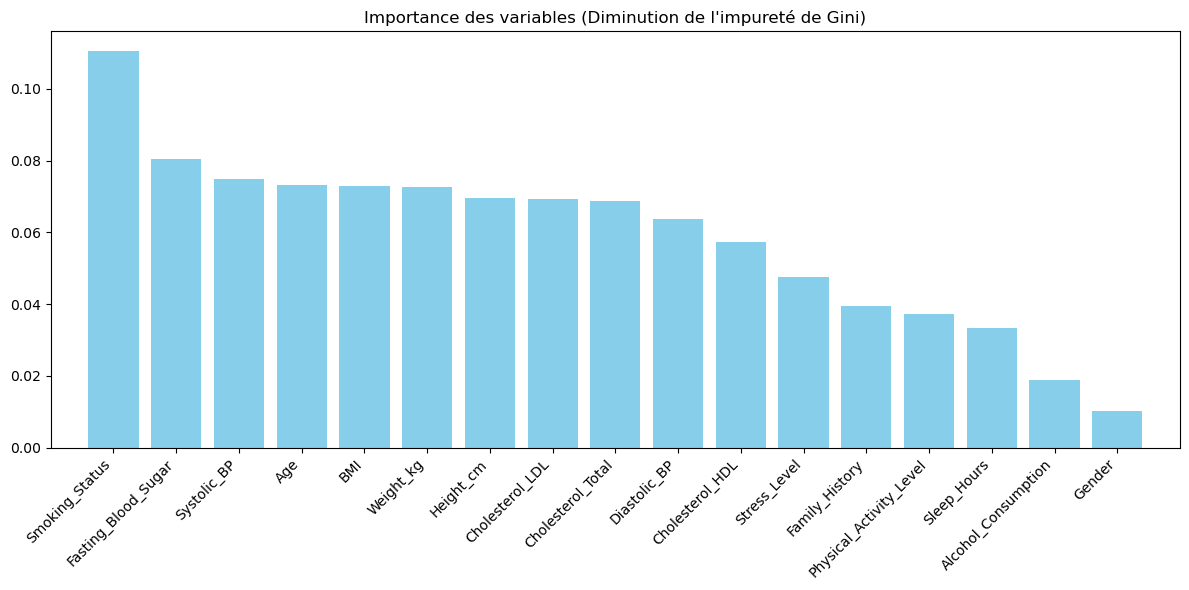

In [23]:
# Optimisation du paramètre max_features par validation croisée
# On teste de 2 à 8 variables tirées aléatoirement pour chaque nœud
param_rf = [{"max_features": list(range(2, 9, 1))}]

# On active oob_score=True
forest = RandomForestClassifier(n_estimators=100, random_state=randomseed, oob_score=True)
rf = GridSearchCV(forest, param_rf, cv=5, n_jobs=-1)
rfOpt = rf.fit(X_train, y_train)

# Paramètre optimal
print("Meilleur score (Accuracy) = %f, Meilleur paramètre = %s" % (rfOpt.best_score_, rfOpt.best_params_))

# Récupération du meilleur modèle pour lire le score OOB
best_rf = rfOpt.best_estimator_
print("Erreur Out-Of-Bag (OOB) : %f" % (1 - best_rf.oob_score_))

# Erreur de prévision sur le test
print("Erreur de prévision sur le test : %f" % (1 - rfOpt.score(X_test, y_test)))

# Prévision et matrice de confusion
y_chap_rf = rfOpt.predict(X_test)
table_rf = pd.crosstab(y_chap_rf, y_test, rownames=['Prédit'], colnames=['Observé'])
print("\nMatrice de confusion Random Forest :\n", table_rf)

# --- Importance décroissante des variables  ---
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

print("\nImportance des variables :")
for f in range(X_train.shape[1]):
    print(X_train.columns[indices[f]], importances[indices[f]])

# Graphe des importances 
plt.figure(figsize=(12, 6))
plt.title("Importance des variables (Diminution de l'impureté de Gini)")
plt.bar(range(X_train.shape[1]), importances[indices], color="skyblue")
# On ajoute une rotation pour que les noms de tes variables soient lisibles
plt.xticks(range(X_train.shape[1]), X_train.columns[indices].tolist(), rotation=45, ha="right")
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout() # Évite que les labels soient coupés
plt.show()

Le modèle Random Forest, avec un paramètre max_features optimal fixé à 2, atteint une Accuracy de 74,03 % sur le jeu de test. Cette performance représente une petite amélioration par rapport au modèle CART (73,10 %), validant l'efficacité de l'agrégation de 100 arbres de décision. L'erreur OOB (Out-Of-Bag) de 0,288 est très proche de l'erreur constatée sur le jeu de test, ce qui démontre la stabilité du modèle et l'absence de surapprentissage significatif.


L'agrégation des arbres permet une meilleure résolution de l'espace des variables : le modèle réduit le nombre de faux négatifs à 444 (contre 498 pour le modèle CART) et celui de faux positifs à 335 (contre 309).

Le score d'importance (basé sur la réduction de l'impureté de Gini) classe Smoking_Status (0,102) et Fasting_Blood_Sugar (0,079) comme les variables contributives les plus fortes. D'un point de vue algorithmique, cette distribution indique que le modèle tire profit de l'ensemble des variables disponibles pour construire ses frontières de décision. 

### 1.5 Gradient boosting

Nous allons maintenant appliquer une méthode de gradient boosting, qui construit plusieurs arbres successifs afin de corriger progressivement les erreurs des modèles précédents et d’améliorer les performances de prédiction.

In [24]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_curve, roc_auc_score

# Paramètres 
paramGrid = [
    {
        'n_estimators': list(range(100, 601, 50)), 
        'learning_rate': [0.05, 0.1, 0.2, 0.3]
    }
]

# Initialisation du modèle
gbm = GradientBoostingClassifier(random_state=randomseed)

# GridSearchCV avec validation croisée 5 folds
gbm_cv = GridSearchCV(gbm, paramGrid, cv=5, n_jobs=-1, verbose=1)

# Entraînement (utilisation de X_train non normalisé car les arbres sont insensibles à l'échelle)
start_time = time.time()
gbm_opt = gbm_cv.fit(X_train, y_train)
end_time = time.time()

# Affichage des résultats
print(f"\nTemps d'exécution : {end_time - start_time:.2f} secondes")
print(f"Meilleur score (validation croisée) : {gbm_opt.best_score_:.4f}")
print(f"Meilleurs paramètres : {gbm_opt.best_params_}")


OPTIMISATION DU GRADIENT BOOSTING
Fitting 5 folds for each of 44 candidates, totalling 220 fits

Temps d'exécution : 1532.61 secondes
Meilleur score (validation croisée) : 0.7303
Meilleurs paramètres : {'learning_rate': 0.1, 'n_estimators': 100}


In [26]:
# Prédictions et évaluation

yChap = gbm_opt.predict(X_test)  

# Probabilités pour la courbe ROC
probas_ = gbm_opt.predict_proba(X_test)  

# Matrice de confusion
table = pd.crosstab(yChap, y_test)
print("Matrice de confusion (Test) :")
print(table)

# Erreur de test 
print(f"Erreur de test gbm opt = {(1 - gbm_opt.score(X_test, y_test)):.4f}")
print(f"Accuracy Test = {gbm_opt.score(X_test, y_test):.4f}")

# Rapport de classification
print("\nRapport de classification :")
print(classification_report(y_test, yChap))

Matrice de confusion (Test) :
Heart_Disease_Risk     0    1
row_0                        
0                   1406  418
1                    355  821
Erreur de test gbm opt = 0.2577
Accuracy Test = 0.7423

Rapport de classification :
              precision    recall  f1-score   support

           0       0.77      0.80      0.78      1761
           1       0.70      0.66      0.68      1239

    accuracy                           0.74      3000
   macro avg       0.73      0.73      0.73      3000
weighted avg       0.74      0.74      0.74      3000




IMPORTANCE DES VARIABLES - GRADIENT BOOSTING
               Variable  Importance
         Smoking_Status    0.378506
         Family_History    0.141631
            Systolic_BP    0.098823
Physical_Activity_Level    0.085050
    Fasting_Blood_Sugar    0.079363
                    Age    0.061461
           Stress_Level    0.035612
                    BMI    0.031437
        Cholesterol_LDL    0.030952
              Weight_kg    0.014490
      Cholesterol_Total    0.011710
              Height_cm    0.009852
           Diastolic_BP    0.008260
            Sleep_Hours    0.007146
        Cholesterol_HDL    0.004516
    Alcohol_Consumption    0.000937
                 Gender    0.000254


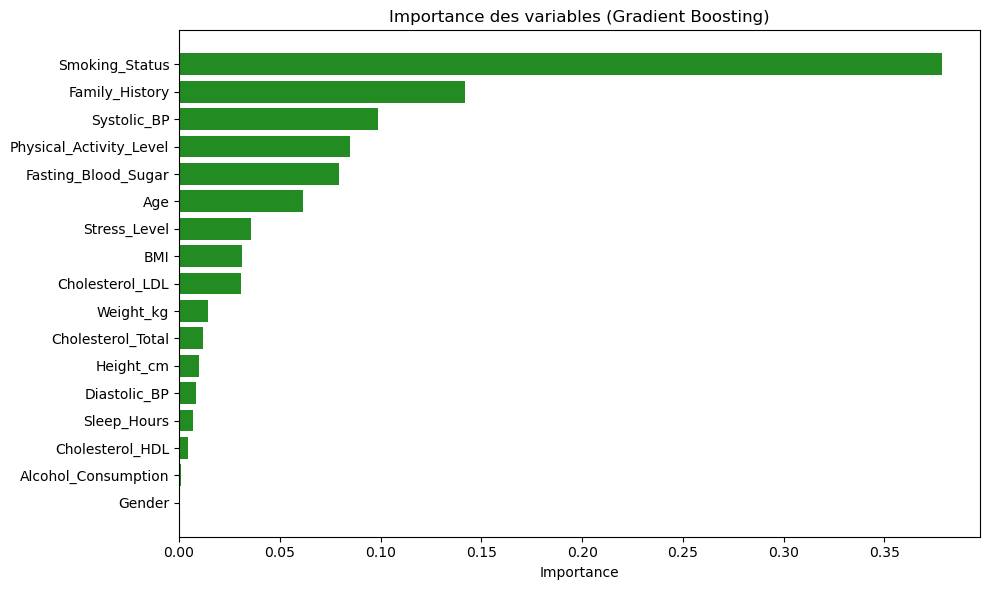

In [27]:
# Importance des variables
feature_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importance': gbm_opt.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("IMPORTANCE DES VARIABLES - GRADIENT BOOSTING")
print("="*60)
print(feature_importance.to_string(index=False))

# Visualisation
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Variable'], feature_importance['Importance'], color='forestgreen')
plt.xlabel('Importance')
plt.title('Importance des variables (Gradient Boosting)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Le Gradient Boosting optimisé (`learning_rate=0.1`, `n_estimators=100`) obtient une accuracy de **0.742** sur le test, cohérente avec le score en validation croisée (0.730), ce qui indique une bonne généralisation.

La matrice de confusion montre que :
- La classe 0 (faible risque) est bien détectée : recall = 0.80
- La classe 1 (risque élevé) reste plus difficile à prédire : recall = 0.66

L'importance des variables révèle que `Smoking_Status` (0.38) et `Family_History` (0.14) dominent largement la prédiction, suivis de `Systolic_BP` et `Physical_Activity_Level`. À l'inverse, `Gender` et `Alcohol_Consumption` contribuent très peu au modèle.

Les performances sont comparables à la régression logistique (0.753), le boosting n'apporte pas d'amélioration significative dans notre cas.

### 1.6 Réseau de Neuronnes

Dans cette section, nous appliquons un réseau de neurones MLP (`MLPClassifier`) pour la prédiction du risque cardiovasculaire. Les hyperparamètres sont optimisés par validation croisée (5 folds) :
- **`hidden_layer_sizes`** : on teste `(10,)`, `(20,)` et `(50,)` 
- **`alpha`** : régularisation L2  : évite le sur-apprentissage
- **`learning_rate_init`** : taux d'apprentissage initial de la descente de gradient

In [28]:
from sklearn.neural_network import MLPClassifier

param_nnet = [{
    "hidden_layer_sizes": [(10,),(20,),(50,)],
    "alpha"             : [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01]
}]

nnet = GridSearchCV(
    MLPClassifier(max_iter=500, random_state=randomseed),
    param_nnet, cv=5, n_jobs=-1
)

nnetOpt = nnet.fit(X_train_scaled, y_train)

print("Meilleur score (Accuracy) = %f, Meilleurs paramètres = %s" % 
      (nnetOpt.best_score_, nnetOpt.best_params_))


Meilleur score (Accuracy) = 0.735250, Meilleurs paramètres = {'alpha': 0.0001, 'hidden_layer_sizes': (10,), 'learning_rate_init': 0.001}


In [29]:
best_nnet = nnetOpt.best_estimator_

y_pred_nnet = best_nnet.predict(X_test_scaled)
score_nnet = accuracy_score(y_test, y_pred_nnet)

print("Accuracy MLP (test) :", score_nnet)
print("\nMatrice de confusion :")
print(pd.DataFrame(
    confusion_matrix(y_test, y_pred_nnet),
    index=["0 réel", "1 réel"],
    columns=["0 prédit", "1 prédit"]
))
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_nnet))

Accuracy MLP (test) : 0.7463333333333333

Matrice de confusion :
        0 prédit  1 prédit
0 réel      1430       331
1 réel       430       809

Rapport de classification :
              precision    recall  f1-score   support

           0       0.77      0.81      0.79      1761
           1       0.71      0.65      0.68      1239

    accuracy                           0.75      3000
   macro avg       0.74      0.73      0.73      3000
weighted avg       0.74      0.75      0.74      3000



Le MLP optimisé (1 couche cachée de 10 neurones, alpha=0.0001, lr=0.001) obtient une
accuracy de 0.746 sur le test, proche du score en validation croisée (0.735),
ce qui indique une bonne généralisation sans sur-apprentissage.

La matrice de confusion montre que :
- Le modèle détecte bien la classe 0 (faible risque) : recall = 0.81
- La classe 1 (risque élevé) est plus difficile à prédire : recall = 0.65

Le MLP est comparable à la régression logistique (0.753), ce qui confirme que
la structure du problème est majoritairement linéaire. Un réseau de seulement 10 neurones
est adéquat dans ce cas, ce qui valide le choix d'une architecture légère.

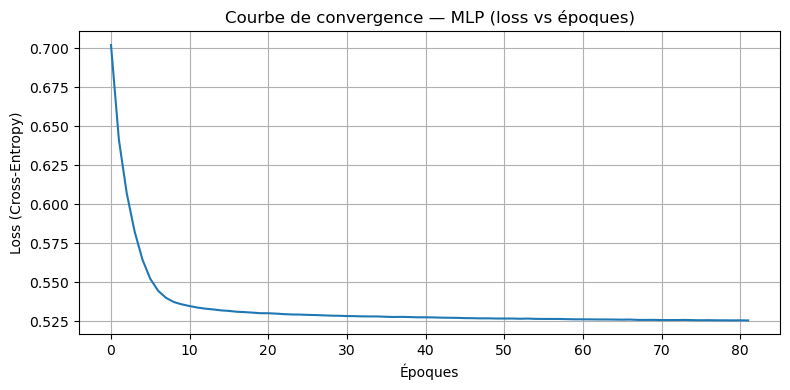

In [30]:
best_nnet_curve = MLPClassifier(
    hidden_layer_sizes=(10,),
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=500,
    random_state=randomseed
)
best_nnet_curve.fit(X_train_scaled, y_train)

plt.figure(figsize=(8, 4))
plt.plot(best_nnet_curve.loss_curve_)
plt.title("Courbe de convergence — MLP (loss vs époques)")
plt.xlabel("Époques")
plt.ylabel("Loss (Cross-Entropy)")
plt.grid(True)
plt.tight_layout()
plt.show()

La courbe de convergence montre que la loss chute rapidement lors des premières époques (0-20), puis se stabilise autour de 0.528 dès l'époque 30 environ, sans divergence. Le réseau converge donc proprement en une80 époques seulement, ce qui confirme qu'une architecture légère (10 neurones, 1 couche) est adéquate pour ce problème.

In [31]:
acc_train_nnet = accuracy_score(y_train, best_nnet.predict(X_train_scaled))
acc_test_nnet  = accuracy_score(y_test,  best_nnet.predict(X_test_scaled))

print("Accuracy Train :", round(acc_train_nnet, 4))
print("Accuracy Test  :", round(acc_test_nnet, 4))

Accuracy Train : 0.7415
Accuracy Test  : 0.7463


| Ensemble | Accuracy |
|----------|----------|
| Train    | 0.7415   |
| Test     | 0.7463   |

Les scores train et test sont quasi identiques (~0.74), ce qui confirme une bonne généralisation sans sur-apprentissage. La régularisation L2 (alpha=0.0001) a bien joué son rôle.

### 1.7 Comparaison entre les différents modeles 

In [ ]:

# Comparaison finale des performances des modèles
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Prédictions de chaque modèle

# Régression logistique
pred_logit = ModelLin.predict(Xr_test)

# LASSO
pred_lasso = logit0pt.predict(Xr_test)

# SVM linéaire
pred_svm_linear = svm_linear.predict(X_test_scaled)

# SVM RBF
pred_svm_rbf = svm_rbf.predict(X_test_scaled)

# SVM optimisé
pred_svm_best = best_svm.predict(X_test_scaled)

# CART
pred_cart = treeOpt.predict(X_test)

# Random Forest
pred_rf = rfOpt.predict(X_test)

# Gradient Boosting
pred_gbm = gbm_opt.predict(X_test)

# Réseau de neurones
pred_nn = best_nnet.predict(X_test_scaled)
pred_nn = (pred_nn > 0.5).astype(int).reshape(-1)

# Tableau comparatif

modeles = {
    "Régression logistique": pred_logit,
    "LASSO L1": pred_lasso,
    "SVM linéaire": pred_svm_linear,
    "SVM RBF": pred_svm_rbf,
    "SVM optimisé": pred_svm_best,
    "CART": pred_cart,
    "Random Forest": pred_rf,
    "Gradient Boosting": pred_gbm,
    "Réseau de neurones": pred_nn
}

resultats = []

for nom, pred in modeles.items():

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    resultats.append([
        nom,
        round(acc, 4),
        round(prec, 4),
        round(rec, 4),
        round(f1, 4)
    ])
# DataFrame final


df_resultats = pd.DataFrame(
    resultats,
    columns=[
        "Modèle",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

# Trier par accuracy décroissante
df_resultats = df_resultats.sort_values(
    by="Accuracy",
    ascending=False
)

print(df_resultats)

                  Modèle  Accuracy  Precision  Recall  F1-score
0  Régression logistique    0.7530     0.7132  0.6723    0.6921
1               LASSO L1    0.7530     0.7132  0.6723    0.6921
8     Réseau de neurones    0.7463     0.7096  0.6529    0.6801
2           SVM linéaire    0.7447     0.7076  0.6505    0.6779
3                SVM RBF    0.7433     0.7084  0.6433    0.6743
4           SVM optimisé    0.7433     0.7062  0.6481    0.6759
7      Gradient Boosting    0.7423     0.6981  0.6626    0.6799
6          Random Forest    0.7393     0.7017  0.6416    0.6703
5                   CART    0.7310     0.7057  0.5981    0.6474


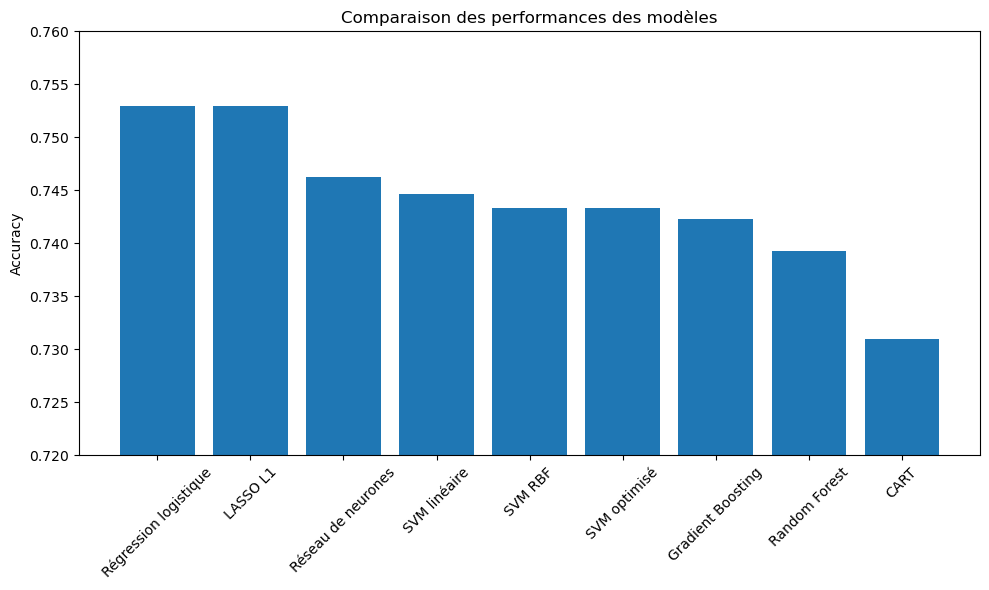

In [39]:
plt.figure(figsize=(10,6))

plt.bar(
    df_resultats["Modèle"],
    df_resultats["Accuracy"]
)

plt.ylim(0.72, 0.76)

plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Comparaison des performances des modèles")

plt.tight_layout()
plt.show()

Les performances des différents modèles restent relativement proches, avec des accuracies comprises entre 73 % et 75 %. La régression logistique obtient même les meilleurs résultats, ce qui suggère que les relations présentes dans les données sont majoritairement simples et proches d’un comportement linéaire.

Les modèles plus complexes (SVM RBF, Random Forest, Gradient Boosting ou réseau de neurones) n’apportent qu’un gain limité, malgré une complexité algorithmique plus élevée.

## 2. Prédiction de la variable cholestérol_LDL

### 2.1 Régression Linéaire 

On s'intéresse maintenant à la prédiction de la variable quantitative `Cholesterol_LDL` 
(mauvais cholestérol) à partir de toutes les variables sauf `Heart_Disease_Risk`.

Contrairement à la partie 1 (classification), il s'agit ici d'un problème de régression :
la variable cible est une variable quantitative. On utilise le modèle linéaire comme base de référence,
évalué par le MSE et le R².

##### Récupération et entrainnement des données

In [40]:
# On récupère les jeu de données sans prendre en compte les nouvelles variables mentionnés dans l'ennoncé
X_chol = df.drop(columns=["Heart_Disease_Risk","Cholesterol_LDL"])
Y_chol = df["Cholesterol_LDL"]

In [41]:
# Vérification de la taille de du type du nouveau jeux de données utilisé
print(X_chol.shape)
print(Y_chol.dtype)
print(Y_chol.head())

(15000, 16)
int64
0    151
1    119
2    124
3    117
4    153
Name: Cholesterol_LDL, dtype: int64


In [44]:
X_train_chol, X_test_chol, y_train_chol, y_test_chol = train_test_split(
    X_chol, Y_chol, test_size=0.2, random_state=randomseed)

# Vérification de la taille de l'échantillon apprentissage et celle de l'échantillon test
print("Taille apprentissage :", X_train_chol.shape[0])
print("Taille test          :", X_test_chol.shape[0])

Taille apprentissage : 12000
Taille test          : 3000


In [45]:
# Normalisation
scaler_chol = StandardScaler()
scaler_chol.fit(X_train_chol)
Xr_train_chol = scaler_chol.transform(X_train_chol)
Xr_test_chol  = scaler_chol.transform(X_test_chol)

Le modèle des Moindres Carrés Ordinaires (MCO) cherche les coefficients $\beta$ qui minimisent
l'erreur quadratique entre les valeurs prédites et les valeurs réelles :

$$
\hat{\beta} = \underset{\beta}{\arg\min} \sum_{i=1}^{n} (Y_i - X_i \beta)^2 = (X^T X)^{-1} X^T Y
$$

Dans un premier lieu on ne prend aucune contrainte sur les coefficients.


In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

LM_Chol = LinearRegression()


LM_Chol.fit(Xr_train_chol,y_train_chol)

y_pred_chol_train = LM_Chol.predict(Xr_train_chol)
y_pred_chol_test = LM_Chol.predict(Xr_test_chol)

print(f"MSE  Train : {mean_squared_error(y_train_chol, y_pred_chol_train):.4f}")
print(f"MSE  Test  : {mean_squared_error(y_test_chol,  y_pred_chol_test):.4f}")
print(f"R²   Train : {r2_score(y_train_chol, y_pred_chol_train):.4f}")
print(f"R²   Test  : {r2_score(y_test_chol,  y_pred_chol_test):.4f}")


MSE  Train : 99.4759
MSE  Test  : 101.6226
R²   Train : 0.6944
R²   Test  : 0.6640


Le modèle linéaire explique 66% de la variance de `Cholesterol_LDL` (R² = 0.664), ce qui est un résultat correct pour un modèle aussi simple. La légère différence entre le train (R²=0.694) et le test (R²=0.664) indique un très léger sur-apprentissage. Le modèle généralise bien. Le MSE obtenu sur l’échantillon test est de 101.62, ce qui correspond à une erreur quadratique moyenne (RMSE) d’environ 10 mg/dL.

Age                         0.101241
Gender                      0.000455
Height_cm                   0.533856
Weight_kg                  -0.991123
BMI                         0.615241
Systolic_BP                 0.280129
Diastolic_BP               -0.263067
Cholesterol_Total          15.009529
Cholesterol_HDL            -0.052791
Fasting_Blood_Sugar         0.007973
Smoking_Status              0.106617
Alcohol_Consumption         0.062514
Physical_Activity_Level    -0.060329
Family_History             -0.085822
Stress_Level                0.105698
Sleep_Hours                -0.032128
dtype: float64


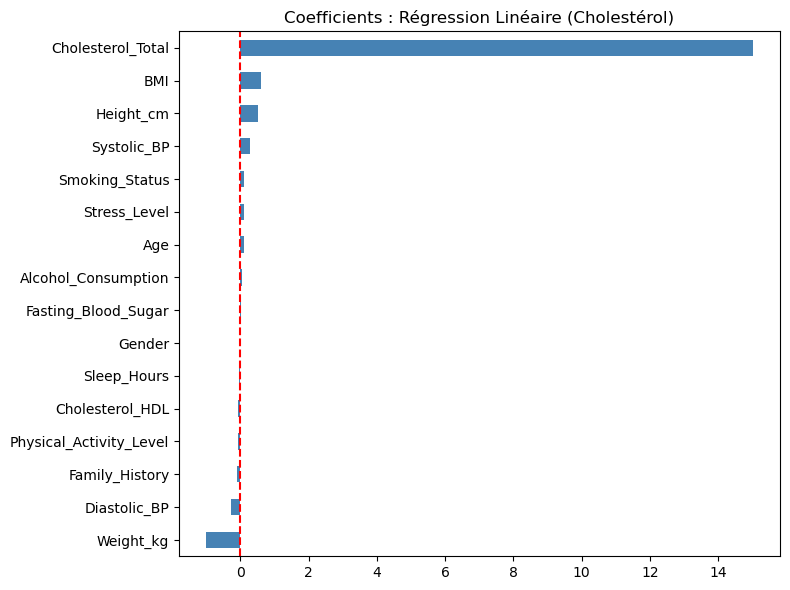

In [47]:
# Récupérer les coefficients du modèle entraîné
coef_chol = pd.Series(LM_Chol.coef_, index=X_chol.columns)

# Trier et tracer
coef_chol.sort_values().plot(kind='barh', figsize=(8, 6), color='steelblue')
print(coef_chol)
plt.title("Coefficients : Régression Linéaire (Cholestérol)")
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

Le graphe des coefficients révèle une forte disparité entre les variables.`Cholesterol_Total` domine très largement avec un coefficient d'environ 15, ce qui est cohérent avec la matrice de corrélation établie lors de l'analyse exploratoire qui montrait déjà la corrélation la plus forte entre ces deux variables. Les autres variables ont des coefficients proches de zéro. On note cependant que `Weight_kg` présente un coefficient négatif alors que sa corrélation avec `Cholesterol_LDL` était positive; ceci s'explique par la multicolinéarité avec `BMI`, deux variables très fortement corrélées entre elles, ce qui pousse le modèle à leur attribuer des signes opposés pour éviter de compter deux fois le même effet.



##### 2.1.1 Pénalisation Lasso L1
On applique maintenant une pénalisation Lasso (L1) sur la régression linéaire.
L'objectif est double : réduire le sur-apprentissage et effectuer une sélection 
automatique de variables en poussant certains coefficients exactement à zéro.

Dans un premier temps on utilise l'alpha par défaut (alpha=1) pour observer 
l'effet de la pénalisation, puis on optimisera alpha par validation croisée.

MSE = 101.76984582691672
R2  = 0.663516469239062

Variables éliminées  : 15
Variables conservées : 1


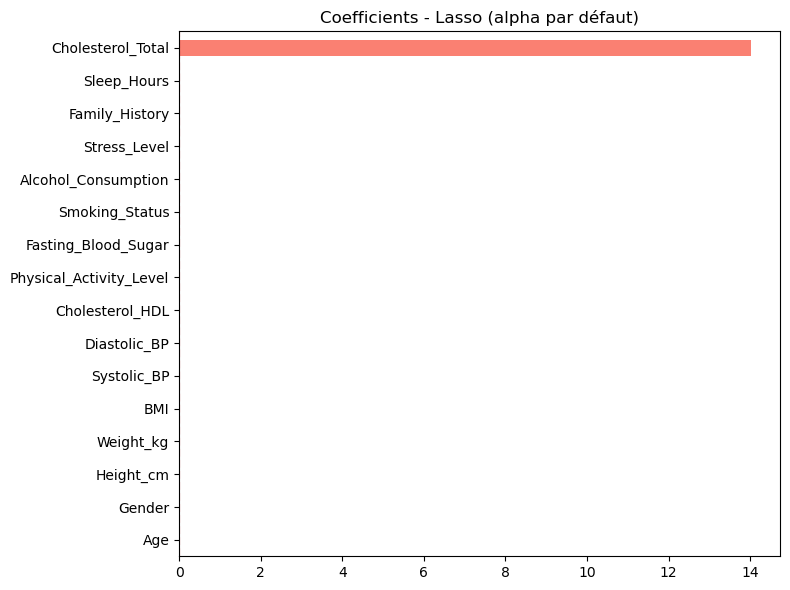

In [ ]:
# Initialisation du modele Lasso ( par défaut alpha = 1)
regLasso_chol = linear_model.Lasso()
regLasso_chol.fit(Xr_train_chol, y_train_chol)

#  Réalisation de la prédiction
prev_chol = regLasso_chol.predict(Xr_test_chol)

# Pérformances 
print("MSE =", mean_squared_error(y_test_chol, prev_chol))
print("R2  =", r2_score(y_test_chol, prev_chol))

# Récupération des coefficients
coef_lasso_chol = pd.Series(regLasso_chol.coef_, index=X_chol.columns)
print(f"\nVariables éliminées  : {sum(coef_lasso_chol == 0)}")
print(f"Variables conservées : {sum(coef_lasso_chol != 0)}")

# Affichage des coefficients
coef_lasso_chol.sort_values().plot(kind='barh', figsize=(8, 6), color='salmon')
plt.title("Coefficients - Lasso (alpha par défaut)")
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

Avec l'alpha par défaut la pénalisation est forte, presque toutes les variables sont réduites à zéro à l'exception de `Cholesterol_Total` qui conserve un coefficient d'environ 14. Cela confirme ce qu'on observait déjà dans le modèle simple : `Cholesterol_Total` est la seule variable suffisamment informative pour résister à la pénalisation. Ce résultat illustre bien le comportement du Lasso, il opère une sélection agressive et ne retient que l'essentiel. L'alpha par défaut reste cependant trop fort pour capturer les contributions plus subtiles des autres variables.

In [50]:
param = [{"alpha": [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1]}]

# Optimisation par validation croisée
regLasso_opt = GridSearchCV(linear_model.Lasso(max_iter=10000), param, cv=10, n_jobs=-1)
regLassoOpt_chol = regLasso_opt.fit(Xr_train_chol, y_train_chol)

print("Meilleur R2    =", round(regLassoOpt_chol.best_score_, 4))
print("Meilleur alpha =", regLassoOpt_chol.best_params_)

# Prédiction
prev_chol_opt = regLassoOpt_chol.predict(Xr_test_chol)

print("MSE =", round(mean_squared_error(y_test_chol, prev_chol_opt), 4))
print("R2  =", round(r2_score(y_test_chol, prev_chol_opt), 4))

Meilleur R2    = 0.6936
Meilleur alpha = {'alpha': 0.2}
MSE = 101.3843
R2  = 0.6648


Le Lasso optimisé par validation croisée trouve un alpha optimal = 0.2, une pénalisation modérée qui conserve les variables les plus informatives tout en éliminant les moins pertinentes.

| Modèle | MSE Test | R² Test |
|---|---|---|
| Régression linéaire (MCO) | 101.62 | 0.664 |
| Lasso (alpha=0.2) | 101.38 | 0.665 |

Les performances sont quasi identiques au modèle MCO, le Lasso n'apporte pas d'amélioration significative en termes de R², ce qui suggère que la structure linéaire du modèle est le vrai facteur limitant, pas le nombre de variables.

Variables éliminées  : 14
Variables conservées : 2
Détails des variables conservées : 
 Cholesterol_Total    14.828848
Age                   0.003424
dtype: float64


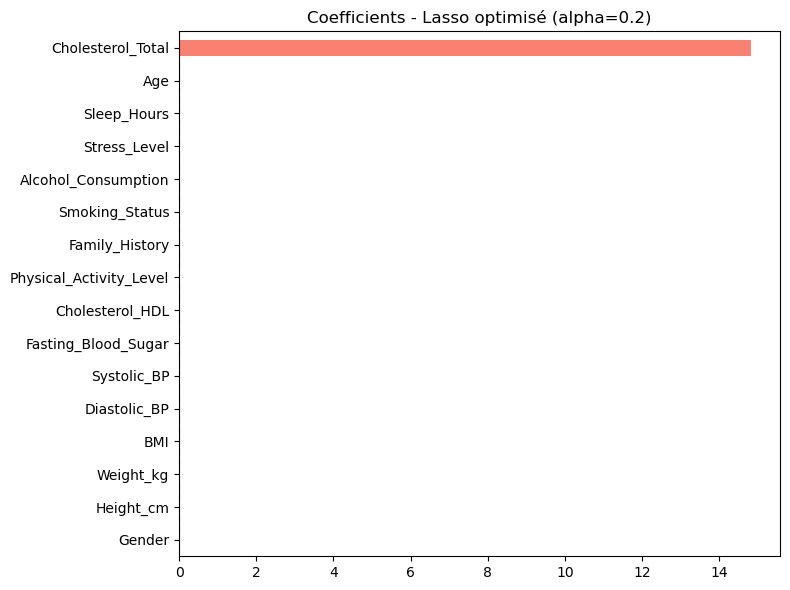

In [51]:
#  Ré-estimation avec alpha optimal pour afficher les coefficients 
regLasso_final = linear_model.Lasso(
    alpha=regLassoOpt_chol.best_params_['alpha'], 
    max_iter=10000)
regLasso_final.fit(Xr_train_chol, y_train_chol)

coef_lasso_opt = pd.Series(regLasso_final.coef_, index=X_chol.columns)
print(f"Variables éliminées  : {sum(coef_lasso_opt == 0)}")
print(f"Variables conservées : {sum(coef_lasso_opt != 0)}")

# Affichage des variables ayant des coefficients non nulls
non_zero_coefs = coef_lasso_opt[coef_lasso_opt != 0]


print("Détails des variables conservées : \n",non_zero_coefs.sort_values(ascending=False))

# Graphique pour les coefficients
coef_lasso_opt.sort_values().plot(kind='barh', figsize=(8, 6), color='salmon')
plt.title(f"Coefficients - Lasso optimisé (alpha={regLassoOpt_chol.best_params_['alpha']})")
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

Avec l'alpha optimal ( alpha = 0.2), le Lasso est beaucoup plus sélectif, il élimine 14 variables sur 16 et ne conserve que `Cholesterol_Total` et `Age`.`Cholesterol_Total` domine largement, tandis que `Age` contribue de façon marginale (0.003). Toutes les autres variables sont jugées insuffisamment informatives 
par rapport à la pénalisation imposée. Cela confirme que dans un cadre linéaire, `Cholesterol_Total` concentre à lui seul l'essentiel de l'information prédictive sur `Cholesterol_LDL`.

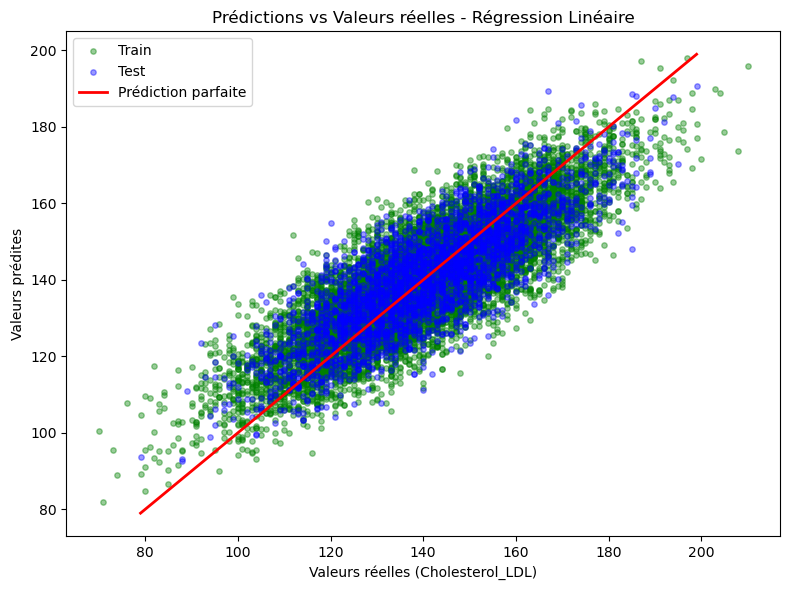

In [53]:
y_test_num  = y_test_chol.astype(float)
y_train_num = y_train_chol.astype(float)

plt.figure(figsize=(8, 6))
plt.scatter(y_train_num, LM_Chol.predict(Xr_train_chol),
            alpha=0.4, color='green', s=15, label='Train')
plt.scatter(y_test_num, y_pred_chol_test,
            alpha=0.4, color='blue', s=15, label='Test')

min_val = float(y_test_num.min())
max_val = float(y_test_num.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', lw=2, label='Prédiction parfaite')

plt.xlabel("Valeurs réelles (Cholesterol_LDL)")
plt.ylabel("Valeurs prédites")
plt.title("Prédictions vs Valeurs réelles - Régression Linéaire")
plt.legend()
plt.tight_layout()
plt.show()

Le nuage de points suit globalement la diagonale rouge, ce qui confirme le R² de 0.66, le modèle capture bien la tendance générale. On observe cependant une dispersion notable autour de cette droite, en particulier pour les valeurs extrêmes de `Cholesterol_LDL`, ce qui illustre les limites du modèle linéaire.

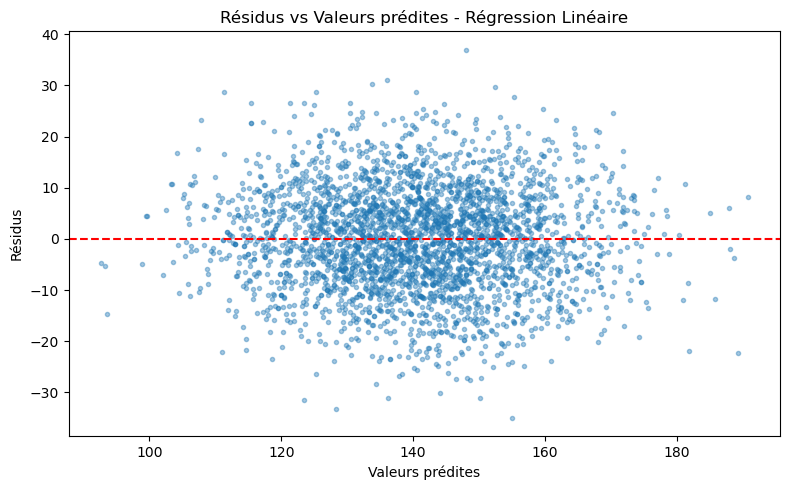

In [54]:
# Graphe des résidus 
residus_chol = y_test_num - y_pred_chol_test

plt.figure(figsize=(8, 5))
plt.plot(y_pred_chol_test, residus_chol, "o", alpha=0.4, markersize=3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus vs Valeurs prédites - Régression Linéaire")
plt.tight_layout()
plt.show()

Le graphe des résidus montre une dispersion relativement symétrique autour de zéro.


## 2.2 Support Vector Regression (SVR)

On considère maintenant un modèle de Support Vector Regression (SVR), extension des SVM aux problèmes de régression.

Contrairement à la régression linéaire, le SVR peut modéliser des relations non linéaires entre les variables explicatives et la variable cible grâce à l’utilisation de noyaux (kernels).

Nous comparerons ici :
- un noyau linéaire,
- un noyau gaussien RBF.

Les hyperparamètres seront optimisés par validation croisée.

In [ ]:
from sklearn.svm import SVR

#### 2.2.1 SVR linéaire

Le noyau linéaire constitue la version la plus simple du SVR.
Il permet de vérifier si une relation essentiellement linéaire suffit à prédire correctement la variable Cholesterol_LDL.

In [57]:
from sklearn.svm import LinearSVR

param_svr_lin = {'C': [0.1, 1, 10],'epsilon': [0.1, 0.5, 1]}

svr_lin = GridSearchCV(LinearSVR(random_state=randomseed,max_iter=10000),param_svr_lin,cv=5,scoring='r2',n_jobs=-1)

svr_lin.fit(Xr_train_chol, y_train_chol)

print("Meilleurs paramètres :", svr_lin.best_params_)
print("Meilleur R² CV :", round(svr_lin.best_score_,4))

y_pred_svr_lin = svr_lin.predict(Xr_test_chol)

mse_svr_lin = mean_squared_error(y_test_chol, y_pred_svr_lin)
r2_svr_lin = r2_score(y_test_chol, y_pred_svr_lin)

print("MSE Test =", round(mse_svr_lin,4))
print("R² Test =", round(r2_svr_lin,4))

Meilleurs paramètres : {'C': 10, 'epsilon': 1}
Meilleur R² CV : 0.6929
MSE Test = 101.6487
R² Test = 0.6639


Le SVR linéaire obtient un meilleur score en validation croisée (R² ≈ 0.693) avec les hyperparamètres optimaux C = 10 et epsilon = 1. Cependant, les performances sur l’échantillon test restent très proches de celles de la régression linéaire classique et du Lasso (R² ≈ 0.664).

Cela indique que la relation entre les variables explicatives et Cholesterol_LDL demeure essentiellement linéaire. Le mécanisme des marges maximales du SVR n’apporte donc pas ici d’amélioration significative en généralisation.

Le faible écart entre les performances d’apprentissage et de test montre néanmoins que le modèle reste stable et ne présente pas de sur-apprentissage important.

#### 2.2.2 SVR avec noyau RBF

Le noyau gaussien RBF permet de modéliser des relations non linéaires entre les variables explicatives et Cholesterol_LDL.

Ce noyau est choisi afin de vérifier si l’introduction de non-linéarités améliore les performances par rapport aux modèles linéaires précédents.

Les hyperparamètres C, gamma et epsilon seront optimisés par validation croisée.

In [58]:
# Hyperparamètres
param_svr_rbf = {'C': [1, 10],'gamma': ['scale', 0.1],'epsilon': [0.1, 0.5]}

# Validation croisée
svr_rbf = GridSearchCV(SVR(kernel='rbf'),param_svr_rbf,cv=5,scoring='r2',n_jobs=-1,verbose=1)

# Entraînement
svr_rbf.fit(Xr_train_chol, y_train_chol)

# Résultats
print("Meilleurs paramètres :", svr_rbf.best_params_)
print("Meilleur R² CV :", round(svr_rbf.best_score_,4))

# Prédictions
y_pred_svr_rbf = svr_rbf.predict(Xr_test_chol)

# Scores
mse_svr_rbf = mean_squared_error(y_test_chol, y_pred_svr_rbf)
r2_svr_rbf = r2_score(y_test_chol, y_pred_svr_rbf)

print("MSE Test =", round(mse_svr_rbf,4))
print("R² Test =", round(r2_svr_rbf,4))

Fitting 5 folds for each of 8 candidates, totalling 40 fits


Meilleurs paramètres : {'C': 10, 'epsilon': 0.5, 'gamma': 'scale'}
Meilleur R² CV : 0.6645
MSE Test = 108.6958
R² Test = 0.6406


Le SVR avec noyau RBF obtient un score de validation croisée de R² ≈ 0.665 avec les paramètres optimaux C = 10, epsilon = 0.5 et gamma = scale.

Cependant, les performances sur l’échantillon test (R² ≈ 0.641) restent inférieures à celles des modèles linéaires précédemment étudiés.

Cela suggère que l’introduction de non-linéarités via le noyau gaussien n’améliore pas la prédiction de Cholesterol_LDL. Les relations entre les variables explicatives et la variable cible semblent donc majoritairement linéaires.

Le noyau RBF apporte ici davantage de flexibilité mais aussi une légère perte de capacité de généralisation.

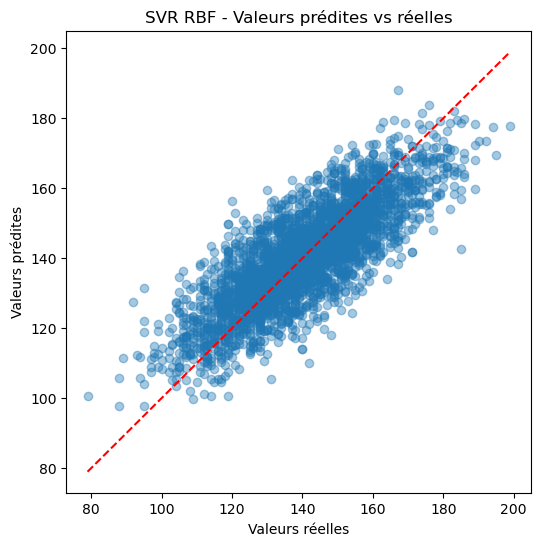

In [59]:
plt.figure(figsize=(6,6))

plt.scatter(y_test_chol, y_pred_svr_rbf, alpha=0.4)

plt.plot(
    [y_test_chol.min(), y_test_chol.max()],
    [y_test_chol.min(), y_test_chol.max()],
    'r--'
)

plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("SVR RBF - Valeurs prédites vs réelles")
plt.show()

Le nuage de points suit globalement la diagonale de prédiction parfaite, ce qui montre que le SVR RBF capture correctement la tendance générale des données.

Cependant, la dispersion autour de cette diagonale reste importante, en particulier pour les valeurs extrêmes de Cholesterol_LDL. Le modèle tend notamment à lisser les prédictions et à sous-estimer les valeurs les plus élevées.

Ces observations sont cohérentes avec les performances quantitatives obtenues (R² ≈ 0.64), légèrement inférieures aux modèles linéaires précédents.

### 2.3 Arbre de régression CART

Nous considérons maintenant un arbre de régression CART pour prédire la variable Cholesterol_LDL.

Les arbres de décision permettent de modéliser des relations non linéaires entre les variables explicatives et la variable cible.

Comme précédemment, les principaux hyperparamètres seront optimisés par validation croisée.

In [60]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

# Optimisation de la profondeur de l'arbre

param = [{"max_depth": list(range(2, 10))}]
tree = GridSearchCV( DecisionTreeRegressor(random_state=randomseed), param, cv=10, n_jobs=-1)

treeOpt = tree.fit(Xr_train_chol, y_train_chol)

# Paramètre optimal
print("Meilleur score R² = %f, Meilleur paramètre = %s"% (treeOpt.best_score_, treeOpt.best_params_))

Meilleur score R² = 0.685367, Meilleur paramètre = {'max_depth': 5}


Le modèle CART a été optimisé par validation croisée sur le paramètre `max_depth`.

La meilleure profondeur obtenue est de 5, avec un score moyen de validation croisée \(R² ≈ 0.685\).

Cette étape permet de contrôler la complexité de l’arbre afin d’éviter le sur-apprentissage.

In [61]:

# Prévision de l'échantillon test
y_pred_tree = treeOpt.predict(Xr_test_chol)

# Métriques
mse_tree = mean_squared_error(
    y_test_chol,
    y_pred_tree
)

rmse_tree = np.sqrt(mse_tree)

mae_tree = mean_absolute_error(
    y_test_chol,
    y_pred_tree
)

r2_tree = r2_score(
    y_test_chol,
    y_pred_tree
)

print("MSE Test =", round(mse_tree,4))
print("RMSE Test =", round(rmse_tree,4))
print("MAE Test =", round(mae_tree,4))
print("R² Test =", round(r2_tree,4))

MSE Test = 103.4678
RMSE Test = 10.1719
MAE Test = 8.1456
R² Test = 0.6579


L’arbre de régression CART obtient un score (R² ≈ 0.658) sur l’échantillon test.

Les performances restent proches de celles des modèles linéaires précédents, ce qui indique que le modèle capture correctement une partie importante de la variabilité du LDL.

L’erreur RMSE d’environ 10 mg/dL reste globalement acceptable dans ce contexte de prédiction.

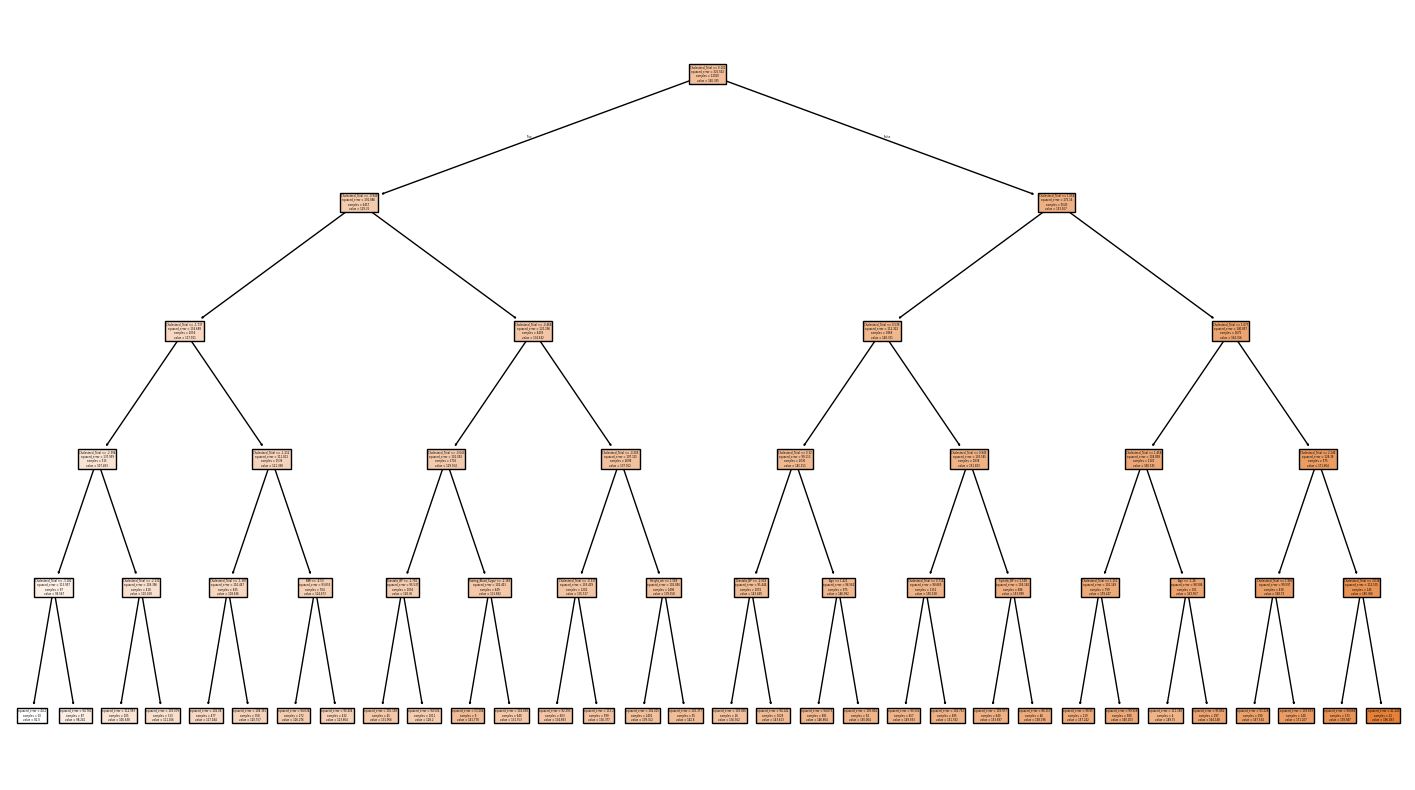

In [63]:
from sklearn.tree import plot_tree

treeG = DecisionTreeRegressor(
    max_depth=treeOpt.best_params_['max_depth'],
    random_state=randomseed
)

treeG.fit(Xr_train_chol, y_train_chol)

plt.figure(figsize=(18,10))

plot_tree(
    treeG,
    feature_names=X_chol.columns.tolist(),
    filled=True
)

plt.show()

L’arbre de décision segmente progressivement les observations selon différentes variables explicatives.

Les premières divisions correspondent aux variables les plus informatives du modèle, en particulier `Cholesterol_Total`, qui apparaît comme le principal facteur explicatif.

Importance des variables (Prédiction du LDL) :

Cholesterol_Total          0.997290
Age                        0.000662
Diastolic_BP               0.000636
BMI                        0.000419
Height_cm                  0.000345
Fasting_Blood_Sugar        0.000328
Systolic_BP                0.000320
Weight_kg                  0.000000
Gender                     0.000000
Cholesterol_HDL            0.000000
Smoking_Status             0.000000
Alcohol_Consumption        0.000000
Physical_Activity_Level    0.000000
Family_History             0.000000
Stress_Level               0.000000
Sleep_Hours                0.000000
dtype: float64


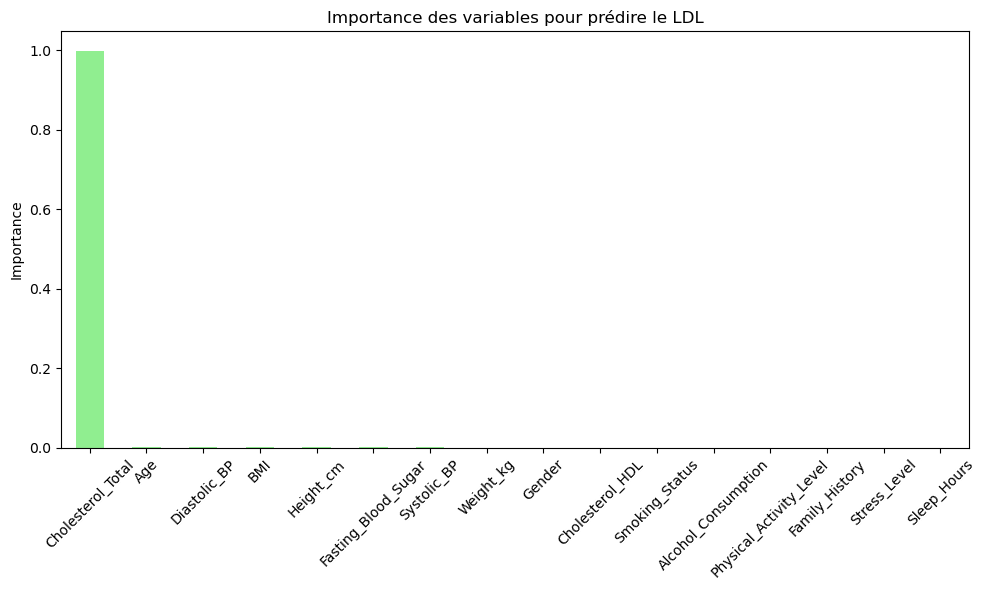

In [64]:
# Importance des variables
importance = pd.Series(
    treeG.feature_importances_,
    index=X_chol.columns
)

# Tri décroissant
importance = importance.sort_values(
    ascending=False
)

# Affichage des valeurs
print(
    "Importance des variables (Prédiction du LDL) :\n"
)

print(importance)

# Graphique
plt.figure(figsize=(10,6))

importance.plot(
    kind='bar',
    color='lightgreen'
)

plt.ylabel("Importance")

plt.title(
    "Importance des variables pour prédire le LDL"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Nous analysons maintenant les résidus du modèle, c’est-à-dire l’écart entre les valeurs réelles et les valeurs prédites.

Un bon modèle doit produire des résidus répartis de manière relativement aléatoire autour de zéro, sans structure particulière.

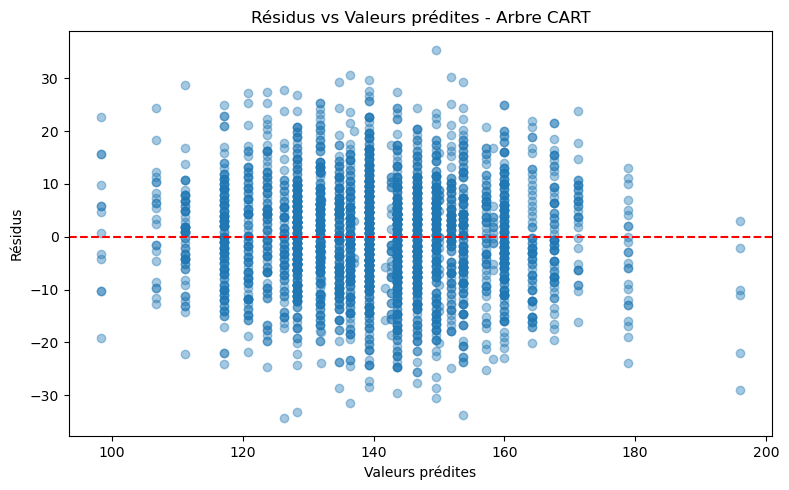

In [65]:
# Résidus
residus_tree = y_test_chol - y_pred_tree

plt.figure(figsize=(8,5))

plt.plot(y_pred_tree, residus_tree, "o", alpha=0.4)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")

plt.title("Résidus vs Valeurs prédites - Arbre CART")

plt.tight_layout()
plt.show()

Les résidus restent globalement répartis autour de zéro sans structure très marquée, ce qui indique que le modèle capture correctement la tendance générale des données.

Les bandes verticales observées proviennent du fonctionnement par partitions de l’arbre CART, qui produit des prédictions discrètes par régions.


Les performances obtenues avec l’arbre CART restent correctes, mais ce type de modèle présente souvent une variance élevée : de petites variations des données peuvent modifier fortement la structure de l’arbre.

Afin d’obtenir un modèle plus stable et potentiellement plus performant, nous considérons maintenant une méthode d’ensemble basée sur plusieurs arbres de décision : le Random Forest Regressor.

### 2.3 Random Forest Regressor

On considère maintenant une forêt aléatoire de régression (Random Forest Regressor).

Contrairement aux modèles précédents, cette méthode repose sur un ensemble d’arbres de décision construits aléatoirement. Les forêts aléatoires permettent de capturer automatiquement des relations non linéaires et des interactions complexes entre les variables.

Les principaux hyperparamètres seront optimisés par validation croisée.

In [66]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Grille des hyperparamètres

param_rf = [{"max_features": list(range(2, 10, 1))}]

# Validation croisée
rf_reg = GridSearchCV(
    RandomForestRegressor(
        random_state=randomseed
    ),
    param_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Entraînement
rf_reg.fit(X_train_chol, y_train_chol)

# Résultats
print("Meilleurs paramètres :", rf_reg.best_params_)
print("Meilleur R² CV :", round(rf_reg.best_score_,4))

# Prédictions
y_pred_rf = rf_reg.predict(X_test_chol)

# Métriques
mse_rf = mean_squared_error(y_test_chol, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test_chol, y_pred_rf)
r2_rf = r2_score(y_test_chol, y_pred_rf)

print("MSE Test =", round(mse_rf,4))
print("RMSE Test =", round(rmse_rf,4))
print("MAE Test =", round(mae_rf,4))
print("R² Test =", round(r2_rf,4))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Meilleurs paramètres : {'max_features': 7}
Meilleur R² CV : 0.6781
MSE Test = 106.6816
RMSE Test = 10.3287
MAE Test = 8.2851
R² Test = 0.6473


La forêt aléatoire obtient des performances très proches des modèles linéaires précédents avec un R² ≈ 0.663.

Malgré sa capacité à modéliser des relations non linéaires, elle n’apporte pas ici d’amélioration significative, ce qui suggère que la structure des données reste majoritairement linéaire.

Nous analysons maintenant les variables les plus importantes pour la forêt aléatoire ainsi que la qualité globale des prédictions du modèle.

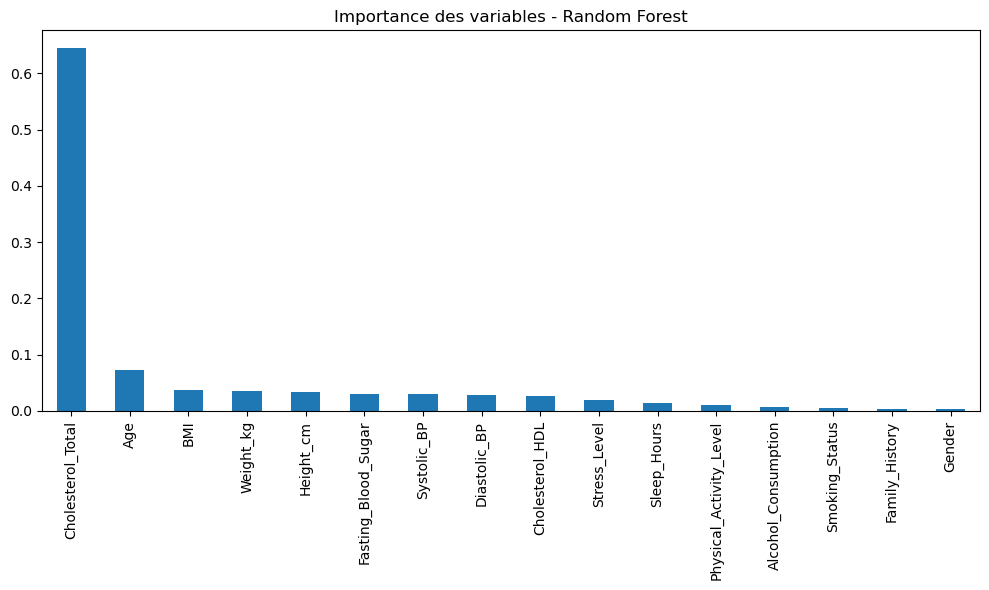

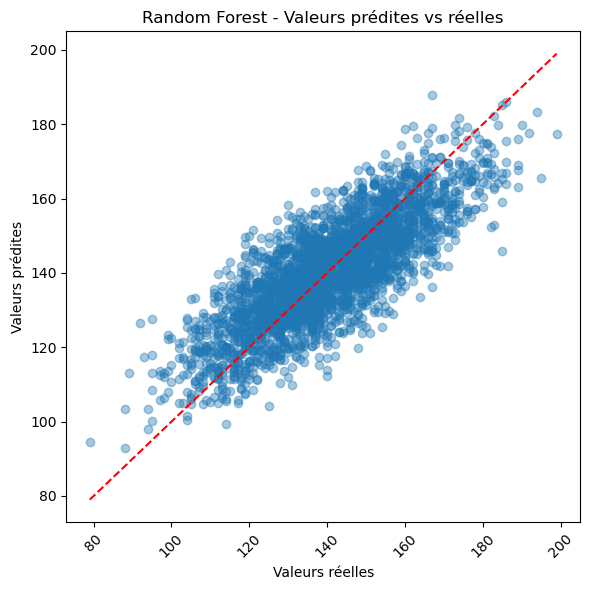

In [67]:
# Importance des variables
importance_rf = pd.Series(
    rf_reg.best_estimator_.feature_importances_,
    index=X_train_chol.columns
)

# Affichage
importance_rf.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Importance des variables - Random Forest")
plt.tight_layout()
plt.show()

# Graphique prédictions vs réalité
plt.figure(figsize=(6,6))

plt.scatter(y_test_chol, y_pred_rf, alpha=0.4)

plt.plot(
    [y_test_chol.min(), y_test_chol.max()],
    [y_test_chol.min(), y_test_chol.max()],
    'r--'
)

plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Random Forest - Valeurs prédites vs réelles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La forêt aléatoire confirme l’importance dominante de `Cholesterol_Total` dans la prédiction du LDL.

Contrairement aux modèles précédents, certaines variables comme l’âge, le BMI, le poids ou la glycémie contribuent également au modèle, même si leur influence reste nettement plus faible.

Le nuage de points reste globalement aligné autour de la diagonale, ce qui indique une bonne cohérence des prédictions sur l’ensemble des observations.

Nous étudions enfin les résidus du modèle afin d’évaluer la répartition des erreurs de prédiction.

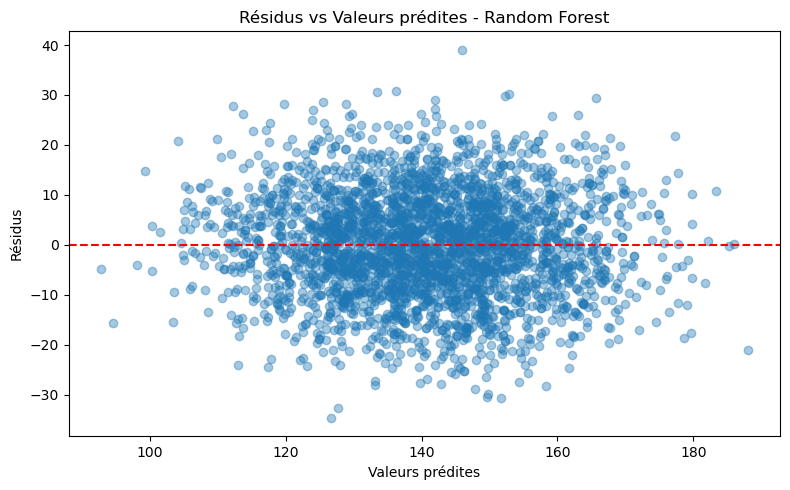

In [68]:
# Résidus
residus_rf = y_test_chol - y_pred_rf

plt.figure(figsize=(8,5))

plt.plot(y_pred_rf, residus_rf, "o", alpha=0.4)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")

plt.title("Résidus vs Valeurs prédites - Random Forest")

plt.tight_layout()
plt.show()

Les résidus restent globalement centrés autour de zéro sans structure très marquée, ce qui indique une bonne stabilité globale du modèle.

La forêt aléatoire n’apporte toutefois pas d’amélioration majeure par rapport aux modèles linéaires.

### 2.4 Gradient Boosting Regressor

On considère maintenant une méthode de boosting appliquée à la régression.

Le Gradient Boosting construit progressivement une succession d’arbres faibles afin de corriger les erreurs des modèles précédents. Cette approche permet souvent d’obtenir de meilleures performances que les arbres simples ou les forêts aléatoires.

Les principaux hyperparamètres seront optimisés par validation croisée.

In [69]:
from sklearn.ensemble import GradientBoostingRegressor

# Grille des hyperparamètres
param_gb = [{"n_estimators": [100, 200],"learning_rate": [0.05, 0.1],"max_depth": [2, 3]}]

# Validation croisée
gb = GridSearchCV(GradientBoostingRegressor(random_state=randomseed),param_gb,cv=5,scoring='r2',n_jobs=-1)

# Entraînement
gbOpt = gb.fit(X_train_chol, y_train_chol)

# Paramètres optimaux
print("Meilleur score R² = %f, Meilleur paramètre = %s"% (gbOpt.best_score_, gbOpt.best_params_))

# Prévision sur l'échantillon test
y_pred_gb = gbOpt.predict(X_test_chol)

# Métriques
mse_gb = mean_squared_error(y_test_chol,y_pred_gb)

rmse_gb = np.sqrt(mse_gb)

mae_gb = mean_absolute_error(y_test_chol,y_pred_gb)

r2_gb = r2_score(y_test_chol,y_pred_gb)

print("MSE Test =", round(mse_gb,4))
print("RMSE Test =", round(rmse_gb,4))
print("MAE Test =", round(mae_gb,4))
print("R² Test =", round(r2_gb,4))

Meilleur score R² = 0.690993, Meilleur paramètre = {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
MSE Test = 101.9731
RMSE Test = 10.0982
MAE Test = 8.0868
R² Test = 0.6628


Le Gradient Boosting obtient des performances très proches des modèles précédents avec un ( R² ≈0.663) sur l’échantillon test.

Malgré sa capacité à modéliser des relations non linéaires plus complexes, l’amélioration reste limitée. Cela suggère que les relations entre les variables explicatives et le LDL sont déjà bien capturées par des modèles plus simples.

Importance des variables (Prédiction du LDL) :

Cholesterol_Total          0.995123
Cholesterol_HDL            0.000886
Height_cm                  0.000689
Stress_Level               0.000616
BMI                        0.000566
Weight_kg                  0.000548
Fasting_Blood_Sugar        0.000511
Age                        0.000420
Diastolic_BP               0.000343
Systolic_BP                0.000172
Sleep_Hours                0.000087
Family_History             0.000028
Alcohol_Consumption        0.000010
Smoking_Status             0.000001
Gender                     0.000000
Physical_Activity_Level    0.000000
dtype: float64


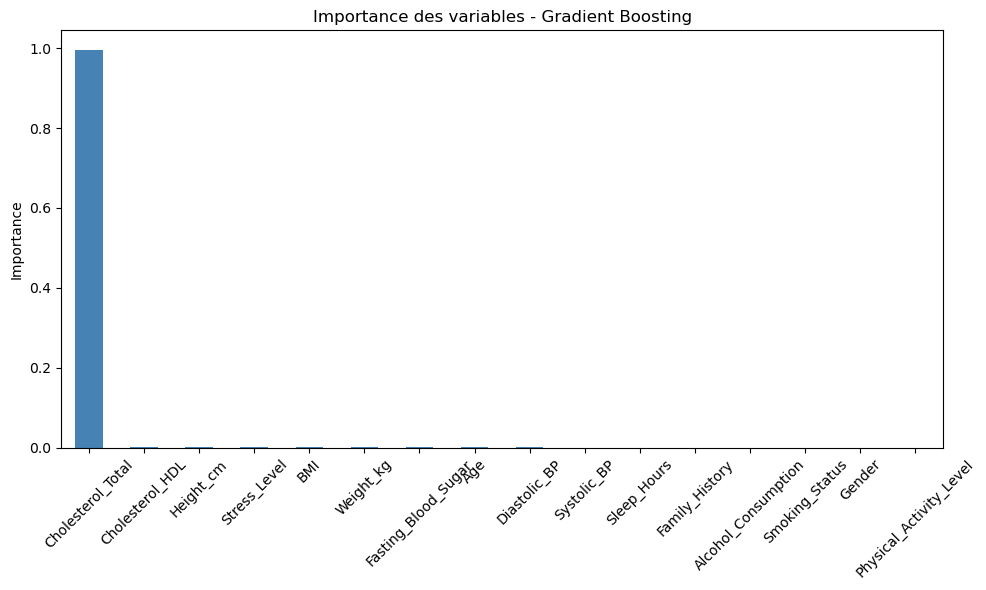

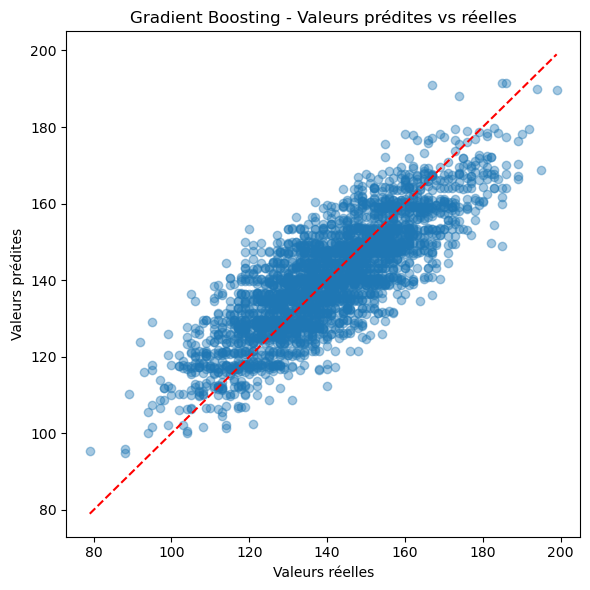

In [70]:
# Importance des variables
importance_gb = pd.Series(gbOpt.best_estimator_.feature_importances_,index=X_train_chol.columns)

# Tri décroissant
importance_gb = importance_gb.sort_values(ascending=False)

# Affichage
print("Importance des variables (Prédiction du LDL) :\n")

print(importance_gb)

# Graphique
plt.figure(figsize=(10,6))

importance_gb.plot(kind='bar',color='steelblue')

plt.ylabel("Importance")

plt.title("Importance des variables - Gradient Boosting")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Graphique prédictions vs réalité
plt.figure(figsize=(6,6))

plt.scatter(y_test_chol,y_pred_gb,alpha=0.4)

plt.plot([y_test_chol.min(), y_test_chol.max()],[y_test_chol.min(), y_test_chol.max()],'r--')

plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")

plt.title("Gradient Boosting - Valeurs prédites vs réelles")

plt.tight_layout()
plt.show()

Le Gradient Boosting confirme à nouveau l’importance largement dominante de `Cholesterol_Total` dans la prédiction du LDL, tandis que les autres variables contribuent très peu au modèle.

Le nuage de points des valeurs prédites versus réelles reste proche de la diagonale, ce qui indique une bonne cohérence globale des prédictions.

Les résultats obtenus restent très similaires à ceux des modèles précédents, ce qui suggère que les méthodes plus complexes n’apportent ici qu’un gain limité.

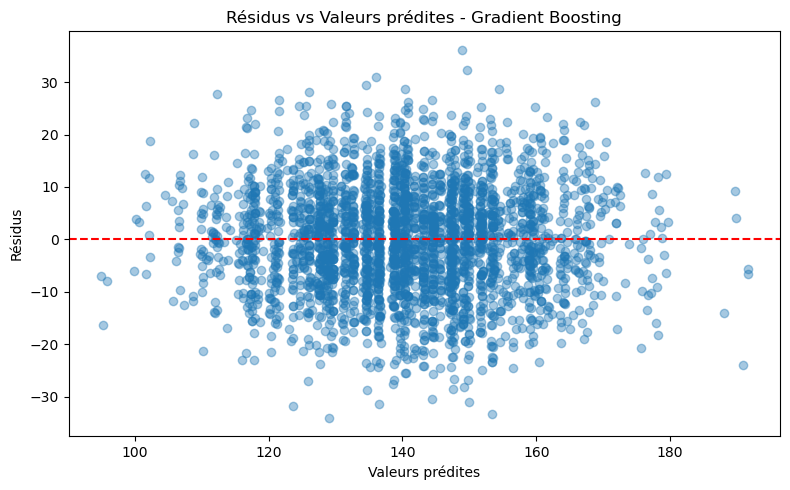

In [ ]:
# Résidus
residus_gb = y_test_chol - y_pred_gb

plt.figure(figsize=(8,5))

plt.plot(y_pred_gb,residus_gb,"o",alpha=0.4)

plt.axhline(0,color='red',linestyle='--')

plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")

plt.title("Résidus vs Valeurs prédites - Gradient Boosting")

plt.tight_layout()
plt.show()

Les résidus restent globalement répartis autour de zéro sans structure particulière marquée, ce qui suggère que le modèle capture correctement la tendance générale des données.

### 2.5 Réseaux de neurones: MLP Regressor

On applique maintenant un **réseau de neurones MLP** pour la régression de `Cholesterol_LDL`.
On utilise `MLPRegressor` de scikit-learn, avec les mêmes hyperparamètres optimisés 
par validation croisée que pour la classification :
- **`hidden_layer_sizes`** : architecture du réseau
- **`alpha`** : régularisation L2
- **`learning_rate_init`** : taux d'apprentissage

In [71]:
from sklearn.neural_network import MLPRegressor

# Grille des hyperparamètres
param_mlp = {
    'hidden_layer_sizes': [(10,), (20,)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001]
}

# Validation croisée
mlp_reg = GridSearchCV(
    MLPRegressor(
        max_iter=1000,
        random_state=randomseed
    ),
    param_mlp,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Entraînement
mlp_reg.fit(Xr_train_chol, y_train_chol)

# Meilleurs paramètres
print("Meilleurs paramètres :", mlp_reg.best_params_)
print("Meilleur R² CV :", round(mlp_reg.best_score_,4))

# Prédictions
y_pred_mlp = mlp_reg.predict(Xr_test_chol)

# Métriques
mse_mlp = mean_squared_error(y_test_chol, y_pred_mlp)
rmse_mlp = np.sqrt(mse_mlp)
mae_mlp = mean_absolute_error(y_test_chol, y_pred_mlp)
r2_mlp = r2_score(y_test_chol, y_pred_mlp)

print("MSE Test =", round(mse_mlp,4))
print("RMSE Test =", round(rmse_mlp,4))
print("MAE Test =", round(mae_mlp,4))
print("R² Test =", round(r2_mlp,4))

Fitting 5 folds for each of 8 candidates, totalling 40 fits


Meilleurs paramètres : {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (10,)}
Meilleur R² CV : 0.6876
MSE Test = 104.0191
RMSE Test = 10.199
MAE Test = 8.1592
R² Test = 0.6561


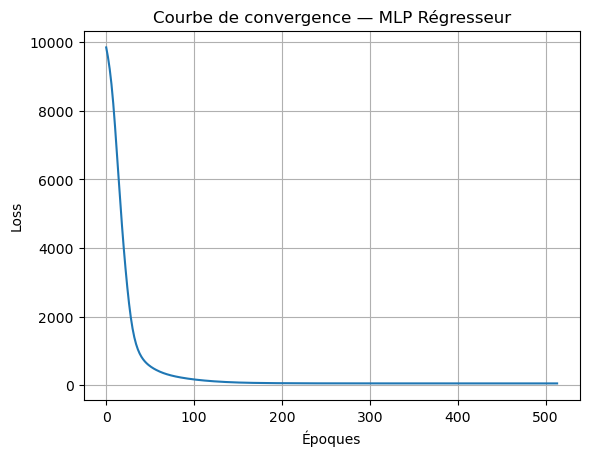

In [72]:
best_mlp = mlp_reg.best_estimator_
plt.plot(best_mlp.loss_curve_)
plt.title("Courbe de convergence — MLP Régresseur")
plt.xlabel("Époques")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

la loss part très haute (~10 000) et chute rapidement durant les 100 premières époques, puis se stabilise autour de 0 sans divergence. Le modèle converge proprement, ce qui valide le choix de `max_iter=1000`.

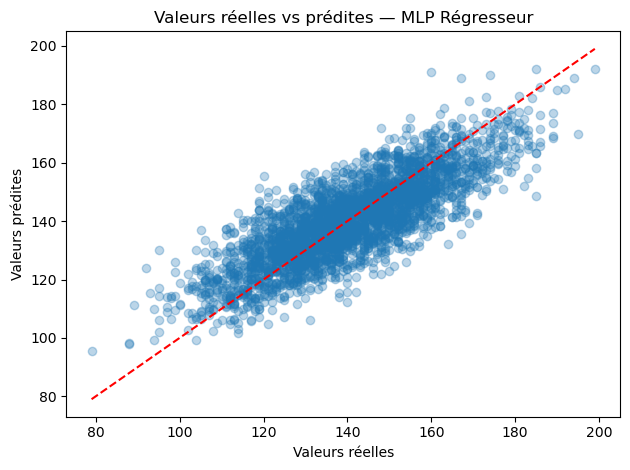

In [73]:
plt.scatter(y_test_chol, y_pred_mlp, alpha=0.3)
plt.plot([y_test_chol.min(), y_test_chol.max()], 
         [y_test_chol.min(), y_test_chol.max()], 'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Valeurs réelles vs prédites — MLP Régresseur")
plt.tight_layout()
plt.show()

Les points s'alignent bien autour de la droite rouge (y=x), ce qui confirme que le modèle capture correctement la tendance générale. On note une légère dispersion autour de la diagonale (cohérente avec RMSE=10.20) et quelques points extrêmes aux valeurs élevées où le modèle tend à sous-estimer, ce qui est classique pour les observations atypiques.

### 2.6 Comparaison entre les modeles 

In [74]:
comparaison_reg = pd.DataFrame({

    "Modèle": [
        "Régression linéaire",
        "Lasso",
        "LinearSVR",
        "SVR RBF",
        "Arbre CART",
        "Random Forest",
        "Gradient Boosting",
        "Réseau de neurones"
    ],

    "RMSE": [
        np.sqrt(101.6226),      # Régression linéaire
        np.sqrt(101.3843),      # Lasso
        np.sqrt(101.6487),      # LinearSVR
        np.sqrt(108.6958),      # SVR RBF
        rmse_tree,
        rmse_rf,
        rmse_gb,
        rmse_mlp
    ],

    "MAE": [
        mean_absolute_error(y_test_chol, y_pred_chol_test),
        mean_absolute_error(y_test_chol, prev_chol_opt),
        mean_absolute_error(y_test_chol, y_pred_svr_lin),
        mean_absolute_error(y_test_chol, y_pred_svr_rbf),
        mae_tree,
        mae_rf,
        mae_gb,
        mae_mlp
    ],

    "R²": [
        0.6640,
        0.6648,
        0.6639,
        0.6406,
        r2_tree,
        r2_rf,
        r2_gb,
        r2_mlp
    ]

})

# Tri selon le R²
comparaison_reg = comparaison_reg.sort_values(
    by="R²",
    ascending=False
)

comparaison_reg

,Modèle,RMSE,MAE,R²
1,Lasso,10.068977,8.058947,0.664800
0,Régression linéaire,10.080804,8.067059,0.664000
2,LinearSVR,10.082098,8.071646,0.663900
6,Gradient Boosting,10.098171,8.086759,0.662845
4,Arbre CART,10.171910,8.145568,0.657903
7,Réseau de neurones,10.198973,8.159190,0.656080
5,Random Forest,10.328681,8.285140,0.647276
3,SVR RBF,10.425728,8.319667,0.640600


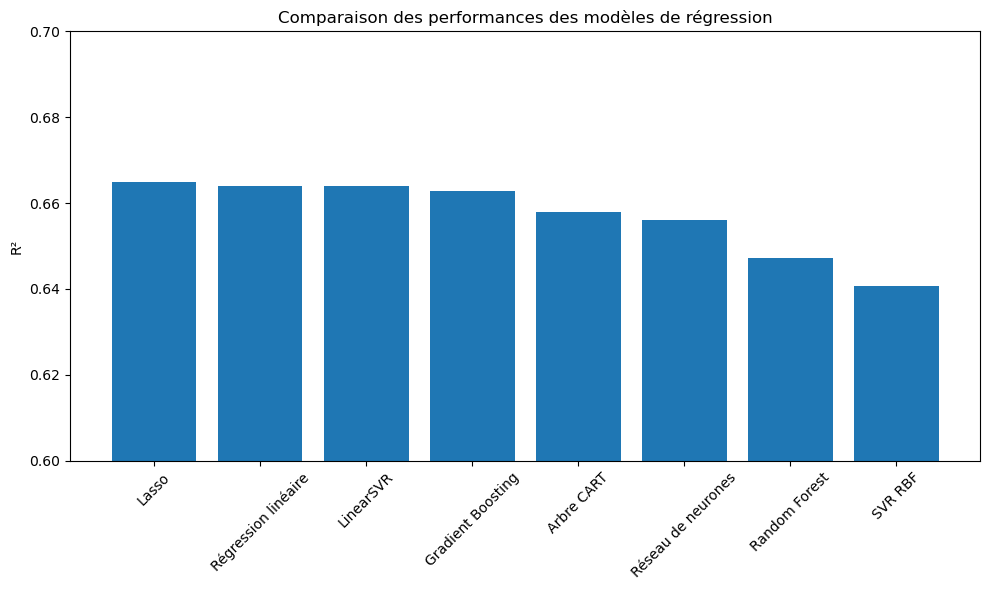

In [76]:
plt.figure(figsize=(10,6))

plt.bar(
    comparaison_reg["Modèle"],
    comparaison_reg["R²"]
)

plt.ylabel("R²")
plt.title("Comparaison des performances des modèles de régression")

plt.xticks(rotation=45)

plt.ylim(0.60, 0.70)

plt.tight_layout()
plt.show()

Le tableau comparatif montre que les performances des différents modèles de régression restent relativement proches. Les méthodes linéaires (régression linéaire et Lasso) obtiennent des résultats comparables aux modèles plus complexes.

Le réseau de neurones, le Gradient Boosting et le Random Forest n’apportent qu’une amélioration limitée du coefficient de détermination \(R^2\), ce qui suggère que la relation entre les variables explicatives et le taux de cholestérol LDL reste globalement simple à modéliser.

Le modèle SVR avec noyau gaussien (RBF) présente des performances légèrement inférieures, probablement en raison d’un surapprentissage ou d’un choix d’hyperparamètres moins adapté au jeu de données.